In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle as pk
import scipy.linalg as sc

from MRPy import MRPy

### OBTENÇÃO DA MATRIZ DE FLEXIBILIDADE E VETOR DESLOCAMENTO

In [2]:
import numpy as np

# Configuração para o Python não encurtar a exibição da matriz no console
np.set_printoptions(linewidth=150)

# 1. Matriz de Flexibilidade (H1)
# Os valores foram extraídos da tabela do FTool (escala original).
H = np.array([
    [0.0108, 0.0097, 0.0086, 0.0075, 0.0065, 0.0054, 0.0043, 0.0032, 0.0022, 0.0011, 0.0000],  # g.d.l. 1
    [0.0097, 0.0459, 0.0491, 0.0491, 0.0462, 0.0412, 0.0344, 0.0265, 0.0180, 0.0093, 0.0011],  # g.d.l. 2
    [0.0086, 0.0491, 0.0871, 0.0891, 0.0853, 0.0770, 0.0650, 0.0504, 0.0344, 0.0180, 0.0022],  # g.d.l. 3
    [0.0075, 0.0491, 0.0891, 0.1240, 0.1210, 0.1100, 0.0938, 0.0734, 0.0504, 0.0265, 0.0032],  # g.d.l. 4
    [0.0065, 0.0462, 0.0853, 0.1210, 0.1490, 0.1380, 0.1190, 0.0938, 0.0650, 0.0344, 0.0043],  # g.d.l. 5
    [0.0054, 0.0412, 0.0770, 0.1100, 0.1380, 0.1580, 0.1380, 0.1100, 0.0770, 0.0412, 0.0054],  # g.d.l. 6 
    [0.0043, 0.0344, 0.0650, 0.0938, 0.1190, 0.1380, 0.1490, 0.1210, 0.0853, 0.0462, 0.0065],  # g.d.l. 7
    [0.0032, 0.0265, 0.0504, 0.0734, 0.0938, 0.1100, 0.1210, 0.1240, 0.0891, 0.0491, 0.0075],  # g.d.l. 8
    [0.0022, 0.0180, 0.0344, 0.0504, 0.0650, 0.0770, 0.0853, 0.0891, 0.0871, 0.0491, 0.0086],  # g.d.l. 9
    [0.0011, 0.0093, 0.0180, 0.0265, 0.0344, 0.0412, 0.0462, 0.0491, 0.0491, 0.0459, 0.0097],  # g.d.l. 10
    [0.0000, 0.0011, 0.0022, 0.0032, 0.0043, 0.0054, 0.0065, 0.0075, 0.0086, 0.0097, 0.0108]   # g.d.l. 11
])

print("Matriz de Flexibilidade H (Valores da Planilha):")
print(H)

# Ajuste para escala SI (m/N)
H = H * 1e-6 

# 2. Teste de Deslocamentos Estáticos
# Cargas de teste: 1000 N em cada g.d.l. 
F = 1000 * np.ones((11, 1)) 

# Calcula os deslocamentos u = H1 * F
U = np.dot(H, F)

print("\n Matriz de deslocamentos U (m):")
print(U)

Matriz de Flexibilidade H (Valores da Planilha):
[[0.0108 0.0097 0.0086 0.0075 0.0065 0.0054 0.0043 0.0032 0.0022 0.0011 0.    ]
 [0.0097 0.0459 0.0491 0.0491 0.0462 0.0412 0.0344 0.0265 0.018  0.0093 0.0011]
 [0.0086 0.0491 0.0871 0.0891 0.0853 0.077  0.065  0.0504 0.0344 0.018  0.0022]
 [0.0075 0.0491 0.0891 0.124  0.121  0.11   0.0938 0.0734 0.0504 0.0265 0.0032]
 [0.0065 0.0462 0.0853 0.121  0.149  0.138  0.119  0.0938 0.065  0.0344 0.0043]
 [0.0054 0.0412 0.077  0.11   0.138  0.158  0.138  0.11   0.077  0.0412 0.0054]
 [0.0043 0.0344 0.065  0.0938 0.119  0.138  0.149  0.121  0.0853 0.0462 0.0065]
 [0.0032 0.0265 0.0504 0.0734 0.0938 0.11   0.121  0.124  0.0891 0.0491 0.0075]
 [0.0022 0.018  0.0344 0.0504 0.065  0.077  0.0853 0.0891 0.0871 0.0491 0.0086]
 [0.0011 0.0093 0.018  0.0265 0.0344 0.0412 0.0462 0.0491 0.0491 0.0459 0.0097]
 [0.     0.0011 0.0022 0.0032 0.0043 0.0054 0.0065 0.0075 0.0086 0.0097 0.0108]]

 Matriz de deslocamentos U (m):
[[5.930e-05]
 [3.305e-04]
 [5.662e-04

### OBTENÇÃO DA MATRIZ DE RIGIDEZ E ANALISE DOS VALORES OBTIDOS EM AMBAS MATRIZES

Matriz de Rigidez K (N/m):
[[ 1.16028656e+08 -3.05867792e+07  2.30270961e+06  2.07382860e+06  4.54233330e+05  7.48593470e+05  2.22802060e+05  4.64718530e+05 -3.64200050e+05
  -3.75972140e+05  1.64750780e+06]
 [-3.05867792e+07  6.31404962e+07 -3.34658570e+07  7.01385700e+04  4.46502470e+05  7.12919100e+04  3.37436030e+05  9.86050000e+02  1.33668700e+04
   3.49048840e+05 -3.75972140e+05]
 [ 2.30270961e+06 -3.34658570e+07  6.31900418e+07 -3.37810275e+07  1.42919203e+06 -3.23320650e+05  1.08264990e+05  3.69613360e+05  2.11851600e+05
   1.33668700e+04 -3.64200050e+05]
 [ 2.07382860e+06  7.01385700e+04 -3.37810275e+07  6.48803239e+07 -3.54940506e+07  1.66709741e+06  5.64317970e+05 -2.17213780e+05  3.69613360e+05
   9.86050000e+02  4.64718530e+05]
 [ 4.54233330e+05  4.46502470e+05  1.42919203e+06 -3.54940506e+07  6.51890935e+07 -3.36977530e+07  1.16537760e+05  5.64317970e+05  1.08264990e+05
   3.37436030e+05  2.22802060e+05]
 [ 7.48593470e+05  7.12919100e+04 -3.23320650e+05  1.66709741e+06 -3

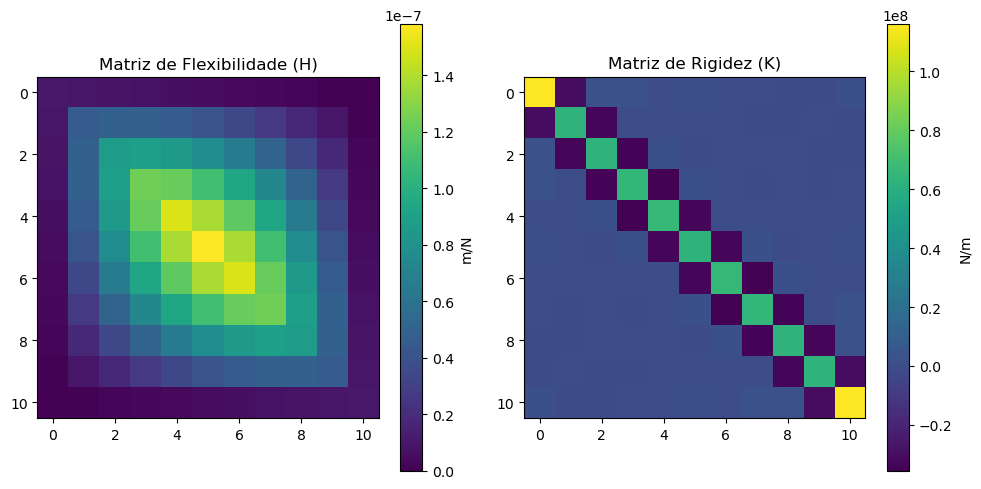

In [3]:
import matplotlib.pyplot as plt

# 3. Matriz de Rigidez (K)
# K é a inversa da matriz de flexibilidade (H).
# Representa as forças necessárias para impor deslocamentos unitários.
K = np.linalg.inv(H)

# Impressão da matriz completa para conferência no relatório
print("Matriz de Rigidez K (N/m):")
print(np.round(K, 2))

# 4. Visualização (Heatmaps)
# Comparação visual entre a matriz de flexibilidade e a matriz de rigidez.
plt.figure(1, figsize=(10, 5))

# Plot da Flexibilidade
plt.subplot(1, 2, 1)
plt.imshow(H)
plt.title('Matriz de Flexibilidade (H)')
plt.colorbar(label='m/N')

# Plot da Rigidez
plt.subplot(1, 2, 2)
plt.imshow(K)
plt.title('Matriz de Rigidez (K)')
plt.colorbar(label='N/m')

plt.tight_layout()
plt.show()

### VERIFICAÇÃO DA CONSISTÊNCIA DA MATRIZ DE RIGIDEZ

In [4]:
# 1. Vetor de Forças (F1)
# O professor utilizou 20.000 N (20 kN) por nó mestre. 
# Adaptamos para um vetor coluna contendo 11 posições (para os 11 g.d.l.s).
Fteste = 20000 * np.ones((11, 1))

# 2. Resolução do Sistema (K * u = F)
# O algoritmo np.linalg.solve é a forma computacionalmente mais eficiente e 
# numericamente estável de resolver sistemas lineares no Python.
Uteste = np.linalg.solve(K, Fteste)

# 3. Impressão dos Resultados

# Visualização do vetor de cargas Fteste completo em N
print('\nVetor de carga Fteste (N):')
print(np.round(Fteste))

# --- Quebra de linha aqui ---
print() 

# O centro de uma estrutura com 11 nós corresponde ao 6º nó.
# Adicionei um \n no início aqui também para garantir o espaçamento
print('\nDeslocamento no centro da estrutura (g.d.l. 6) para vetor de carga Fteste: {0:6.2f} mm'.format(1000 * Uteste[5, 0]))

# Visualização do vetor completo de deslocamentos Uteste em mm
print('\nVetor de deslocamentos Uteste (mm):')
print(np.round(1000 * Uteste, 2))


Vetor de carga Fteste (N):
[[20000.]
 [20000.]
 [20000.]
 [20000.]
 [20000.]
 [20000.]
 [20000.]
 [20000.]
 [20000.]
 [20000.]
 [20000.]]


Deslocamento no centro da estrutura (g.d.l. 6) para vetor de carga Fteste:  18.02 mm

Vetor de deslocamentos Uteste (mm):
[[ 1.19]
 [ 6.61]
 [11.32]
 [14.96]
 [17.25]
 [18.02]
 [17.25]
 [14.96]
 [11.32]
 [ 6.61]
 [ 1.19]]


### OBTENÇÃO DA MATRIZ DE MASSA

#### Relatório Analítico de Levantamento de Carga Equivalente
*Peso Específico do Aço A36 adotado: $\gamma = 77 \text{ kN/m}^3$*

---

#### A. Cálculo das Áreas das Seções (m²)
* **Banzo Inferior ($190 \times 130 \times 10 \text{ mm}$):** $A = [2 \cdot 130 + (190 - 2 \cdot 10)] \cdot 10 = 4300 \text{ mm}^2 =$ **0,004300 m²**
* **Banzo Superior ($190 \times 90 \times 8 \text{ mm}$):** $A = [2 \cdot 90 + (190 - 2 \cdot 8)] \cdot 8 = 2832 \text{ mm}^2 =$ **0,002832 m²**
* **Diagonais/Montantes ($165 \times 60 \times 3 \text{ mm}$):** $A = [2 \cdot 60 + (165 - 2 \cdot 3)] \cdot 3 = 837 \text{ mm}^2 =$ **0,000837 m²**

---

#### B. Verificação de Seções e Taxa Linear (kN/m)
* Banzo Inferior: $0,004300 \text{ m}^2 \cdot 77 \text{ kN/m}^3 =$ **0,3311 kN/m**
* Banzo Superior: $0,002832 \text{ m}^2 \cdot 77 \text{ kN/m}^3 =$ **0,2181 kN/m**
* Diagonais/Montantes: $0,000837 \text{ m}^2 \cdot 77 \text{ kN/m}^3 =$ **0,0644 kN/m**

---

#### C. Apuração do Peso Total por Grupo (kN)
* Banzo Inferior (18,00 m): $18,00 \text{ m} \cdot 0,3311 \text{ kN/m} =$ **5,96 kN**
* Banzo Superior (18,00 m): $18,00 \text{ m} \cdot 0,2181 \text{ kN/m} =$ **3,93 kN**
* Montantes (3,60 m): $3,60 \text{ m} \cdot 0,0644 \text{ kN/m} =$ **0,23 kN**
* Diagonais (40,25 m): $40,25 \text{ m} \cdot 0,0644 \text{ kN/m} =$ **2,64 kN**

---

#### D. Peso Total e Taxa Linear Equivalente (q)
* Peso Total da Estrutura: $5,96 + 3,93 + 0,23 + 2,64 =$ **12,76 kN**
* Taxa Linear Equivalente: $12,76 \text{ kN} / 18,00 \text{ m} =$ **0,709 kN/m**

---

#### E. Cargas Nodais (Áreas de Influência)
* 9 Nós Centrais (1,80 m): $0,709 \text{ kN/m} \cdot 1,80 \text{ m} =$ **1,276 kN**
* 2 Nós de Extremidade (0,90 m): $0,709 \text{ kN/m} \cdot 0,90 \text{ m} =$ **0,638 kN**

In [5]:
import numpy as np

# 1. Definição das massas em kg (Carga_kN * 1000 / 9.81)
m_central = (1.271 * 1000) / 9.81   # Massa para o vão de 1.80m
m_ponta   = (0.635 * 1000) / 9.81   # Massa para o vão de 0.90m

# 2. Preenchimento do vetor de massa (11 g.d.l.)
# Criamos um vetor com o valor central e ajustamos apenas as pontas
m_diag = np.full(11, m_central)
m_diag[0]  = m_ponta
m_diag[-1] = m_ponta

# 3. Montagem da Matriz Diagonal (M1)
M = np.diag(m_diag)

# 4. Impressão para o relatório
print("Matriz de Massa M (kg):")
print(np.round(M, 2))

print(f"\nResumo: Pontas = {m_ponta:.2f} kg | Centro = {m_central:.2f} kg")

Matriz de Massa M (kg):
[[ 64.73   0.     0.     0.     0.     0.     0.     0.     0.     0.     0.  ]
 [  0.   129.56   0.     0.     0.     0.     0.     0.     0.     0.     0.  ]
 [  0.     0.   129.56   0.     0.     0.     0.     0.     0.     0.     0.  ]
 [  0.     0.     0.   129.56   0.     0.     0.     0.     0.     0.     0.  ]
 [  0.     0.     0.     0.   129.56   0.     0.     0.     0.     0.     0.  ]
 [  0.     0.     0.     0.     0.   129.56   0.     0.     0.     0.     0.  ]
 [  0.     0.     0.     0.     0.     0.   129.56   0.     0.     0.     0.  ]
 [  0.     0.     0.     0.     0.     0.     0.   129.56   0.     0.     0.  ]
 [  0.     0.     0.     0.     0.     0.     0.     0.   129.56   0.     0.  ]
 [  0.     0.     0.     0.     0.     0.     0.     0.     0.   129.56   0.  ]
 [  0.     0.     0.     0.     0.     0.     0.     0.     0.     0.    64.73]]

Resumo: Pontas = 64.73 kg | Centro = 129.56 kg


### SALVANDO AS MATRIZES DE FLEXIBILIDADE, RIGIDEZ E MASSA

In [6]:
import os
import pickle as pk

with open('resources/trabalho3_HKM.pk', 'wb') as target:
    pk.dump((H, K, M), target)

### TESTANDO SE A GRAVAÇÃO DO ARQUIVO FUNCIONOU

In [7]:
import pickle as pk
import numpy as np

# 1. Carregamento e Verificação de Integridade
with open('resources/trabalho3_HKM.pk', 'rb') as source:
    H_load, K_load, M_load = pk.load(source)

# 2. Teste lógico de igualdade (np.allclose lida com precisão decimal)
check = np.allclose(H, H_load) and np.allclose(K, K_load) and np.allclose(M, M_load)

# 3. Output direto e funcional
print("--- Verificação de Dados Salvos ---")
print(f"Matrizes: H {H_load.shape} | K {K_load.shape} | M {M_load.shape}")

if check:
    print("\n✔ Sucesso: O arquivo foi gravado corretamente e os dados são idênticos.")
else:
    print("\n❌ Erro: Existe uma divergência entre o arquivo e a memória!")

--- Verificação de Dados Salvos ---
Matrizes: H (11, 11) | K (11, 11) | M (11, 11)

✔ Sucesso: O arquivo foi gravado corretamente e os dados são idênticos.


### CÁLCULO E APRESENTAÇÃO DAS FORMAS MODAIS E FREQUÊNCIAS NATURAIS DE VIBRAÇÃO LIVRE

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pickle as pk
import scipy.linalg as sc

from MRPy import MRPy

# ---------------------------------------------------------
# BLOCO 5: Frequências Naturais e Formas Modais (Matriz Completa)
# ---------------------------------------------------------

def vibration_modes(K, M):

    # 1. Resolução do Problema de Autovalores e Autovetores (11 G.D.L.)
    # Resolve o problema generalizado: K * Phi = w^2 * M * Phi
    # Correção aqui: alterado de "sl" para "sc" para bater com o import lá em cima!
    w2, Phi = sc.eigh(K, M)

    # Garante a ordem crescente dos autovalores
    iw  = w2.argsort()
    w2  = w2[iw]
    Phi = Phi[:,iw]
    
    # 2. Conversão para Frequências em Hz
    wk = np.sqrt(np.real(w2)) # Frequência circular w (rad/s)
    fk = wk / (2 * np.pi)    # Frequência natural fn (Hz)
    
    return fk, wk, Phi

--- Frequências Naturais de Vibração Livre (11 G.D.L.) ---
Modo  1:  16.50 Hz
Modo  2:  39.73 Hz
Modo  3:  63.96 Hz
Modo  4:  86.16 Hz
Modo  5: 106.31 Hz
Modo  6: 124.86 Hz
Modo  7: 138.50 Hz
Modo  8: 152.55 Hz
Modo  9: 159.77 Hz
Modo 10: 216.65 Hz
Modo 11: 219.61 Hz


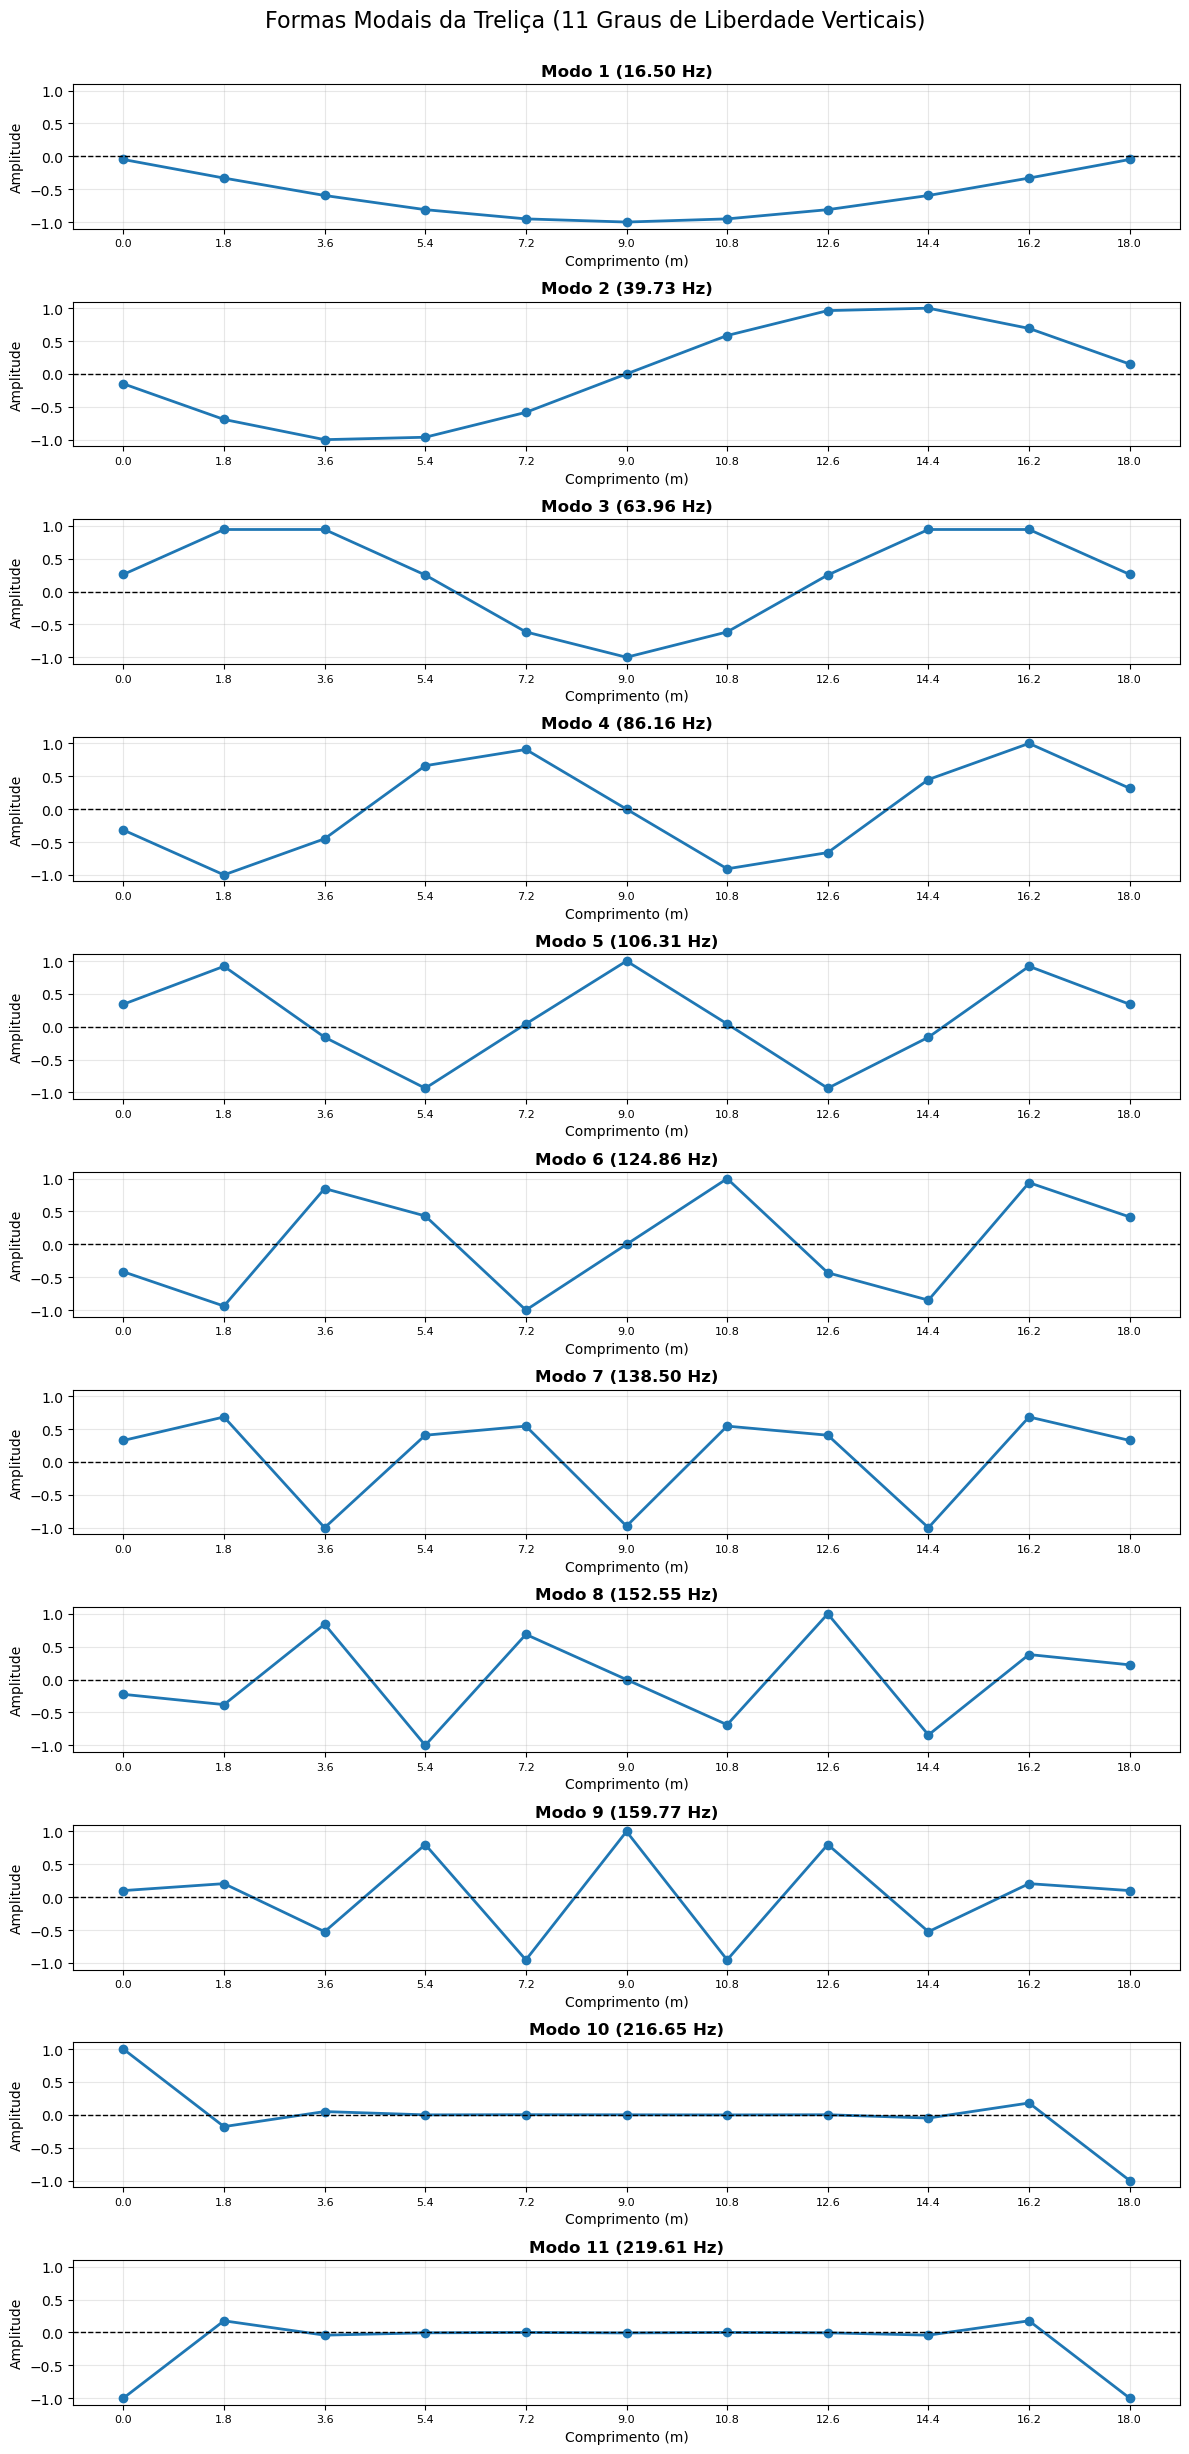

In [9]:
fk, wk, Phi = vibration_modes(K, M)

# 3. Impressão de TODAS as Frequências Naturais
print("--- Frequências Naturais de Vibração Livre (11 G.D.L.) ---")
for i in range(len(fk)):
    print(f"Modo {i+1:2d}: {fk[i]:6.2f} Hz")

# 4. Visualização Gráfica das Formas Modais (Subplots Empilhados)
# Coordenadas X exatas dos 11 nós do banzo superior
x_nos = np.linspace(0.0, 18.0, 11)

# Criando 11 gráficos empilhados verticalmente (11 linhas, 1 coluna)
# Aumentamos a altura (25) para que os gráficos não fiquem espremidos
fig, axes = plt.subplots(11, 1, figsize=(12, 25))
fig.suptitle('Formas Modais da Treliça (11 Graus de Liberdade Verticais)', fontsize=16, y=0.98)

for i in range(11):
    # --- Lógica de escala da aula ---
    # Normaliza a amplitude: divide a forma modal pelo seu maior valor em módulo
    qk = Phi[:, i].copy()
    qk /= np.max(np.abs(qk))
    
    # Plotando cada modo (usando o qk normalizado)
    axes[i].plot(x_nos, qk, marker='o', linestyle='-', color='#1f77b4', linewidth=2)
    axes[i].set_title(f'Modo {i+1} ({fk[i]:.2f} Hz)', fontsize=12, fontweight='bold')
    axes[i].axhline(0, color='black', linewidth=1, linestyle='--') # Eixo neutro
    
    # Fixando a escala vertical para todos os gráficos (1.1 apenas para margem visual)
    axes[i].set_ylim(-1.1, 1.1)
    
    # --- AJUSTE DA ESCALA DO EIXO X PARA BATER COM OS NÓS ---
    axes[i].set_xticks(x_nos)
    axes[i].tick_params(axis='x', labelsize=8) # Fonte menor para não sobrepor os textos
    
    # Para evitar repetição visual, você pode comentar o xlabel se quiser que 
    # apareça apenas no último gráfico de baixo, mas mantive para não perder sua formatação
    axes[i].set_xlabel('Comprimento (m)')
    axes[i].set_ylabel('Amplitude')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
# Ajuste do topo para o título principal não encostar no primeiro gráfico
plt.subplots_adjust(top=0.95) 
plt.show()

In [10]:
# =========================================================
# BLOCO EXTRA: Avaliação dos G.D.L. Críticos (Dinâmico e Estático)
# =========================================================

print("--- 1. ANÁLISE DINÂMICA: AMPLITUDES MÁXIMAS POR MODO ---")
print(f"{'Modo':<6} | {'G.D.L. Máx':<12} | {'Amplitude Máxima':<18}")

# Variáveis para rastrear o recorde dinâmico absoluto da treliça
max_absoluto_din = 0.0
gdl_absoluto_din = 0
modo_absoluto = 0

for k in range(11): # Varre todos os 11 modos
    phi_atual = Phi[:, k]
    idx_max = np.argmax(np.abs(phi_atual))
    gdl_max = idx_max + 1
    amp_max = np.abs(phi_atual[idx_max])
    
    print(f"{k+1:02d}     | Nó {gdl_max:02d}       | {amp_max:.4f}")
    
    if amp_max > max_absoluto_din:
        max_absoluto_din = amp_max
        gdl_absoluto_din = gdl_max
        modo_absoluto = k + 1

print("\n--> RESUMO DINÂMICO:")
print(f"O ponto de maior vibração global ocorre no Nó {gdl_absoluto_din}, durante o Modo {modo_absoluto} (Amplitude Relativa: {max_absoluto_din:.4f}).")

print("\n" + "="*57 + "\n")

print("--- 2. ANÁLISE ESTÁTICA: DESLOCABILIDADE MÁXIMA ---")
# Usando o vetor U (Deslocamentos Estáticos) que você já calculou no notebook
# O comando .flatten() garante que o vetor (11, 1) vire um vetor simples (11,)
U_flat = U.flatten()

print(f"{'Nó':<15} | {'Deslocamento Estático Total (m)':<35}")

max_absoluto_est = 0.0
gdl_absoluto_est = 0

for i in range(11):
    gdl_atual = i + 1
    desloc = np.abs(U_flat[i])
    
    print(f"{gdl_atual:02d}              | {desloc:.6e}")
    
    if desloc > max_absoluto_est:
        max_absoluto_est = desloc
        gdl_absoluto_est = gdl_atual

print("\n--> RESUMO ESTÁTICO:")
print(f"O ponto mais flexível (maior deslocabilidade) sob as cargas de teste é o Nó {gdl_absoluto_est}.")
print(f"O deslocamento máximo gerado foi de {max_absoluto_est:.6e} m.")

print("\n" + "="*57)
print("CONCLUSÃO PARA ESCOLHA DO G.D.L. PARA IMPACTO:")
print(f"- Pelo critério Dinâmico : Nó {gdl_absoluto_din}")
print(f"- Pelo critério Estático : Nó {gdl_absoluto_est}")
print("=========================================================")

--- 1. ANÁLISE DINÂMICA: AMPLITUDES MÁXIMAS POR MODO ---
Modo   | G.D.L. Máx   | Amplitude Máxima  
01     | Nó 06       | 0.0391
02     | Nó 09       | 0.0374
03     | Nó 06       | 0.0374
04     | Nó 02       | 0.0392
05     | Nó 06       | 0.0409
06     | Nó 07       | 0.0366
07     | Nó 09       | 0.0396
08     | Nó 08       | 0.0405
09     | Nó 06       | 0.0403
10     | Nó 01       | 0.0850
11     | Nó 11       | 0.0851

--> RESUMO DINÂMICO:
O ponto de maior vibração global ocorre no Nó 11, durante o Modo 11 (Amplitude Relativa: 0.0851).


--- 2. ANÁLISE ESTÁTICA: DESLOCABILIDADE MÁXIMA ---
Nó              | Deslocamento Estático Total (m)    
01              | 5.930000e-05
02              | 3.305000e-04
03              | 5.662000e-04
04              | 7.480000e-04
05              | 8.625000e-04
06              | 9.012000e-04
07              | 8.625000e-04
08              | 7.480000e-04
09              | 5.662000e-04
10              | 3.305000e-04
11              | 5.930000e-05



### RESPOSTA DINAMICA A CONDIÇÃO INICIAL

#### PELO CRITÉRIO DINAMICO

In [11]:
# =========================================================
# 1. VETORES DE CONDIÇÃO INICIAL
# =========================================================
# u0: Vetor coluna com os deslocamentos iniciais (m)
u0 = np.array([[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]]).T

# v0: Vetor coluna com as velocidades iniciais (m/s)
v0 = np.array([[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0]]).T

print("--- 1. Condições Iniciais Físicas ---")
print("Vetor de Deslocamentos u0 (m):")
print(u0.T)
print("\nVetor de Velocidades v0 (m/s):")
print(v0.T)


# =========================================================
# 2. PROPRIEDADES MODAIS (Massa Modal)
# =========================================================
# Mi_mat: Matriz de massa modal completa (Phi.T * M * Phi)
Mi_mat = np.dot(np.dot(Phi.T, M), Phi)   

print("\n--- 2. Massa Modal ---")
print("Matriz de Massa Modal Completa (deve ser diagonal):")
print(np.round(Mi_mat, 4))

# Mi: Extrai apenas a diagonal principal para os cálculos
Mi = np.diag(Mi_mat)
print("\nVetor da diagonal principal (Mi) para cada modo:")
print(np.round(Mi, 4))


# =========================================================
# 3. PROJEÇÃO MODAL DAS CONDIÇÕES INICIAIS
# =========================================================
# O .flatten() achata a matriz coluna para um vetor 1D simples
qMu0 = np.dot(np.dot(Phi.T, M), u0).flatten()
qMv0 = np.dot(np.dot(Phi.T, M), v0).flatten()

print("\n--- 3. Projeção das Condições Iniciais no Espaço Modal ---")
print("Deslocamentos projetados (qMu0):")
print(np.round(qMu0, 4))
print("\nVelocidades projetadas (qMv0):")
print(np.round(qMv0, 4))

print()

# =========================================================
# 4. CÁLCULO DE FASE (thi) E AMPLITUDE (u0i) - AUTOMATIZADO
# =========================================================
# Este bloco resolve a resposta para cada um dos 11 modos
# sem necessidade de ajustes manuais para u0 ou v0.

print("\n--- 4. CÁLCULO DE FASE (thi) E AMPLITUDE (u0i) ---")

thi = np.zeros(11)
u0i = np.zeros(11)

print(f"{'Modo':<8} | {'Fase (rad)':<12} | {'Amplitude (mm)':<15}")


for k in range(11):
    # O uso do arctan2(numerador, denominador) evita erros de divisão por zero
    # thi = arctan( (w*qMu0) / qMv0 )
    thi[k] = np.arctan2(wk[k] * qMu0[k], qMv0[k])
    
    # Amplitude calculada pela raiz da soma dos quadrados (vetor resultante)
    # u0i = sqrt( (u0_modal)^2 + (v0_modal/w)^2 )
    # Nota: Dividimos por Mi[k] para normalizar pela massa modal do modo k
    termo_u = qMu0[k] / Mi[k]
    termo_v = qMv0[k] / (Mi[k] * wk[k])
    
    u0i[k] = np.sqrt(termo_u**2 + termo_v**2)
        
    print(f"Modo {k+1:02d}  | {thi[k]:10.4f}   | {1000*u0i[k]:12.6f}")

--- 1. Condições Iniciais Físicas ---
Vetor de Deslocamentos u0 (m):
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]

Vetor de Velocidades v0 (m/s):
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]

--- 2. Massa Modal ---
Matriz de Massa Modal Completa (deve ser diagonal):
[[ 1.  0.  0.  0. -0.  0.  0. -0.  0.  0.  0.]
 [ 0.  1.  0. -0. -0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  1. -0.  0.  0.  0.  0. -0. -0. -0.]
 [ 0. -0. -0.  1.  0. -0.  0.  0. -0. -0.  0.]
 [-0. -0.  0.  0.  1.  0.  0. -0.  0.  0.  0.]
 [ 0.  0.  0. -0.  0.  1.  0.  0.  0. -0. -0.]
 [ 0.  0.  0.  0.  0.  0.  1.  0.  0. -0.  0.]
 [-0.  0.  0.  0. -0.  0.  0.  1. -0.  0. -0.]
 [ 0.  0. -0. -0.  0.  0.  0. -0.  1. -0.  0.]
 [ 0.  0. -0. -0.  0. -0. -0.  0. -0.  1.  0.]
 [ 0.  0. -0.  0.  0. -0.  0. -0.  0.  0.  1.]]

Vetor da diagonal principal (Mi) para cada modo:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

--- 3. Projeção das Condições Iniciais no Espaço Modal ---
Deslocamentos projetados (qMu0):
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Velocidades proje

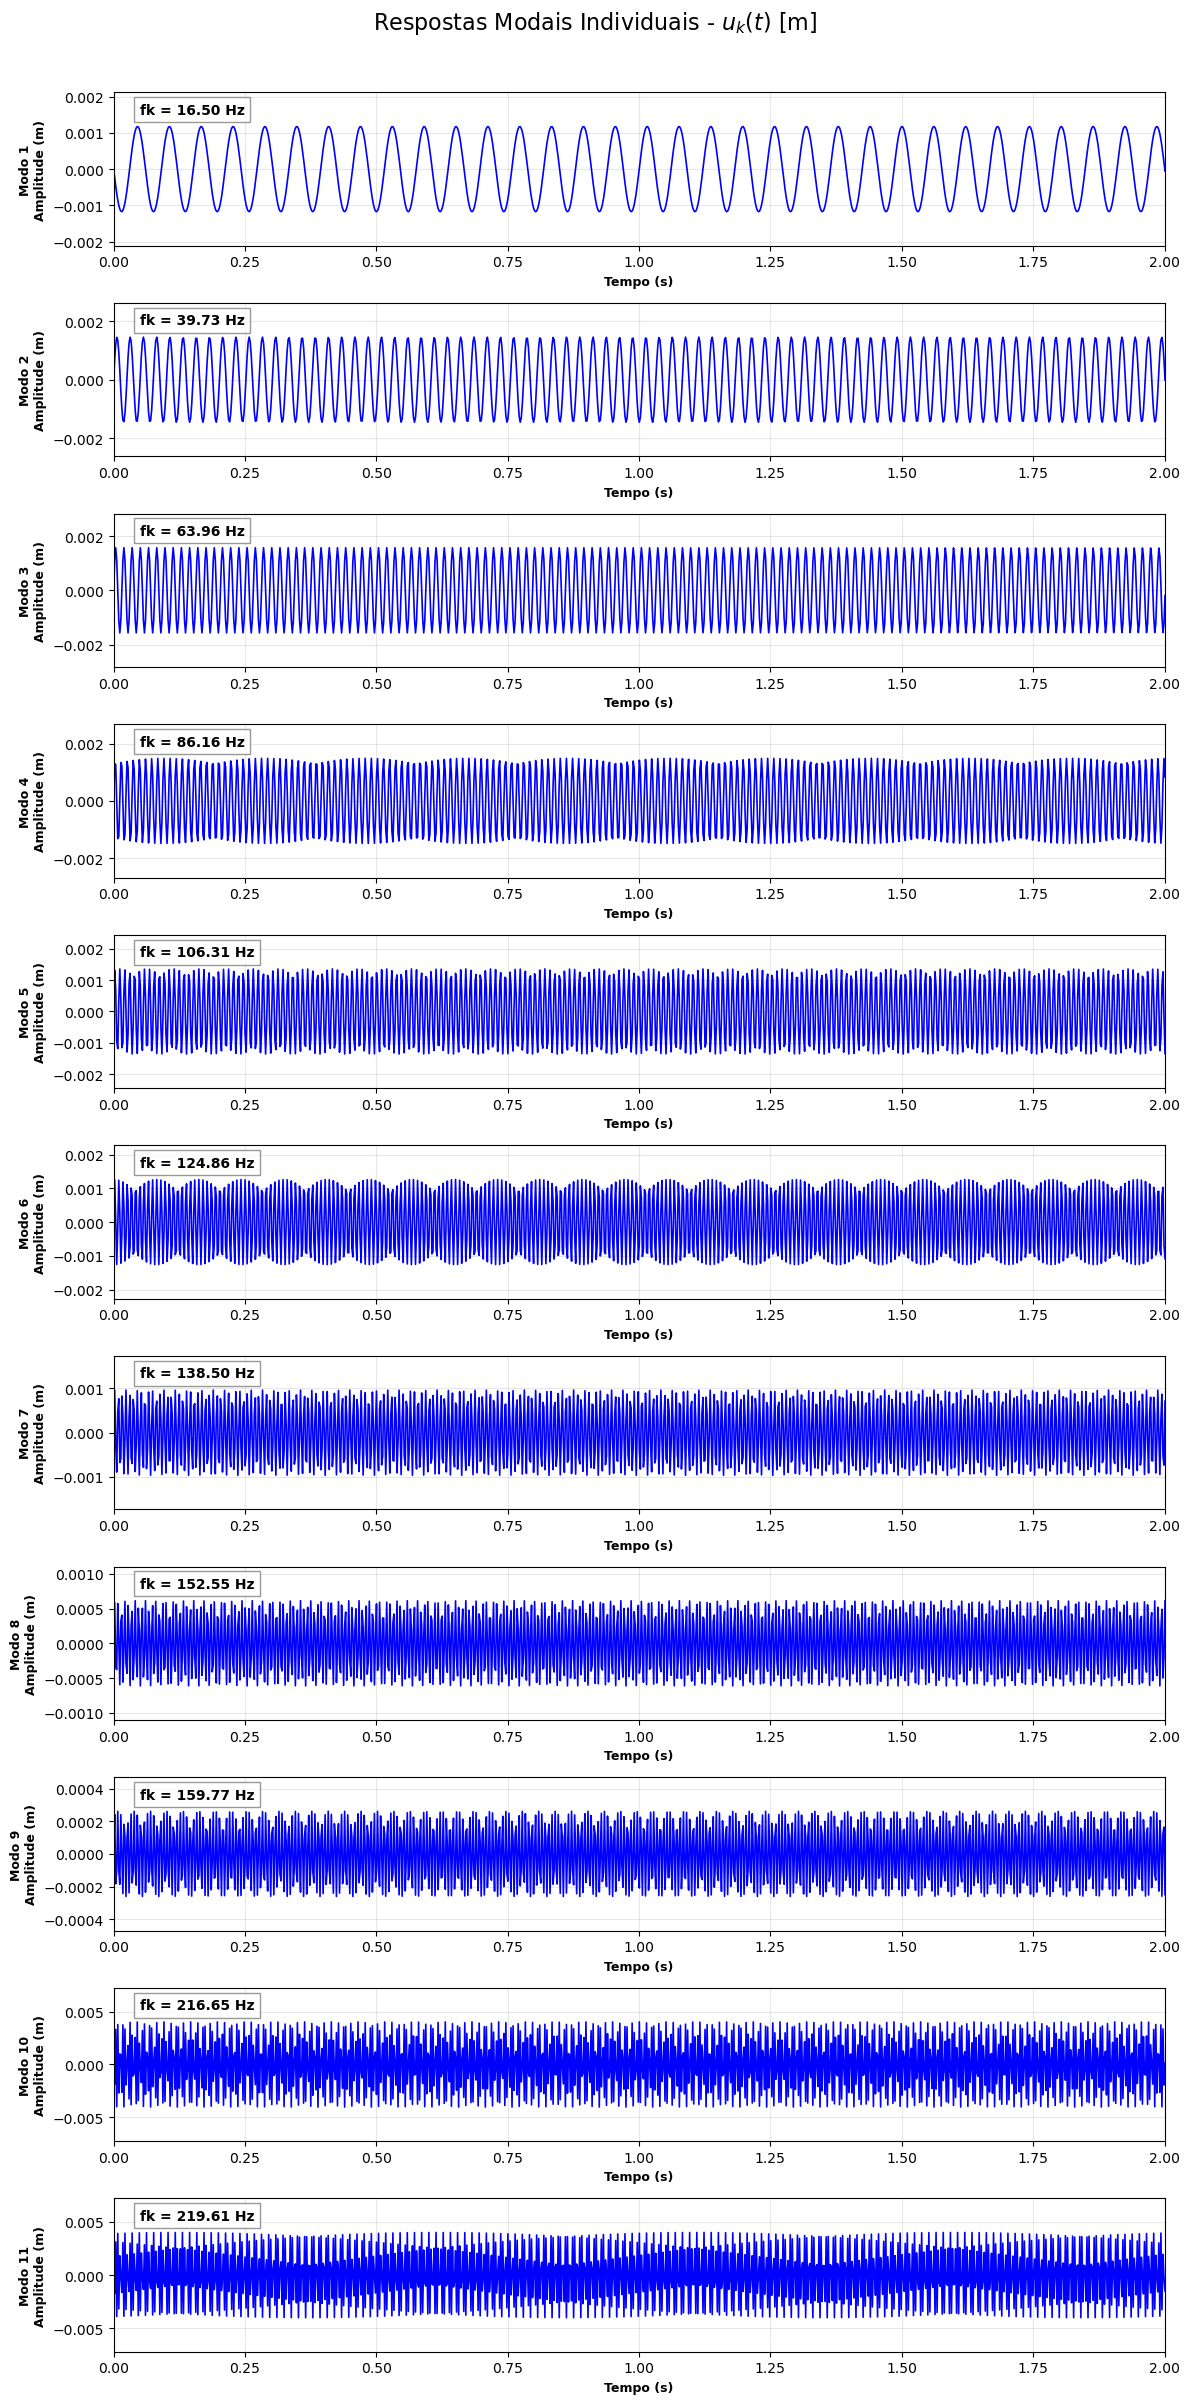

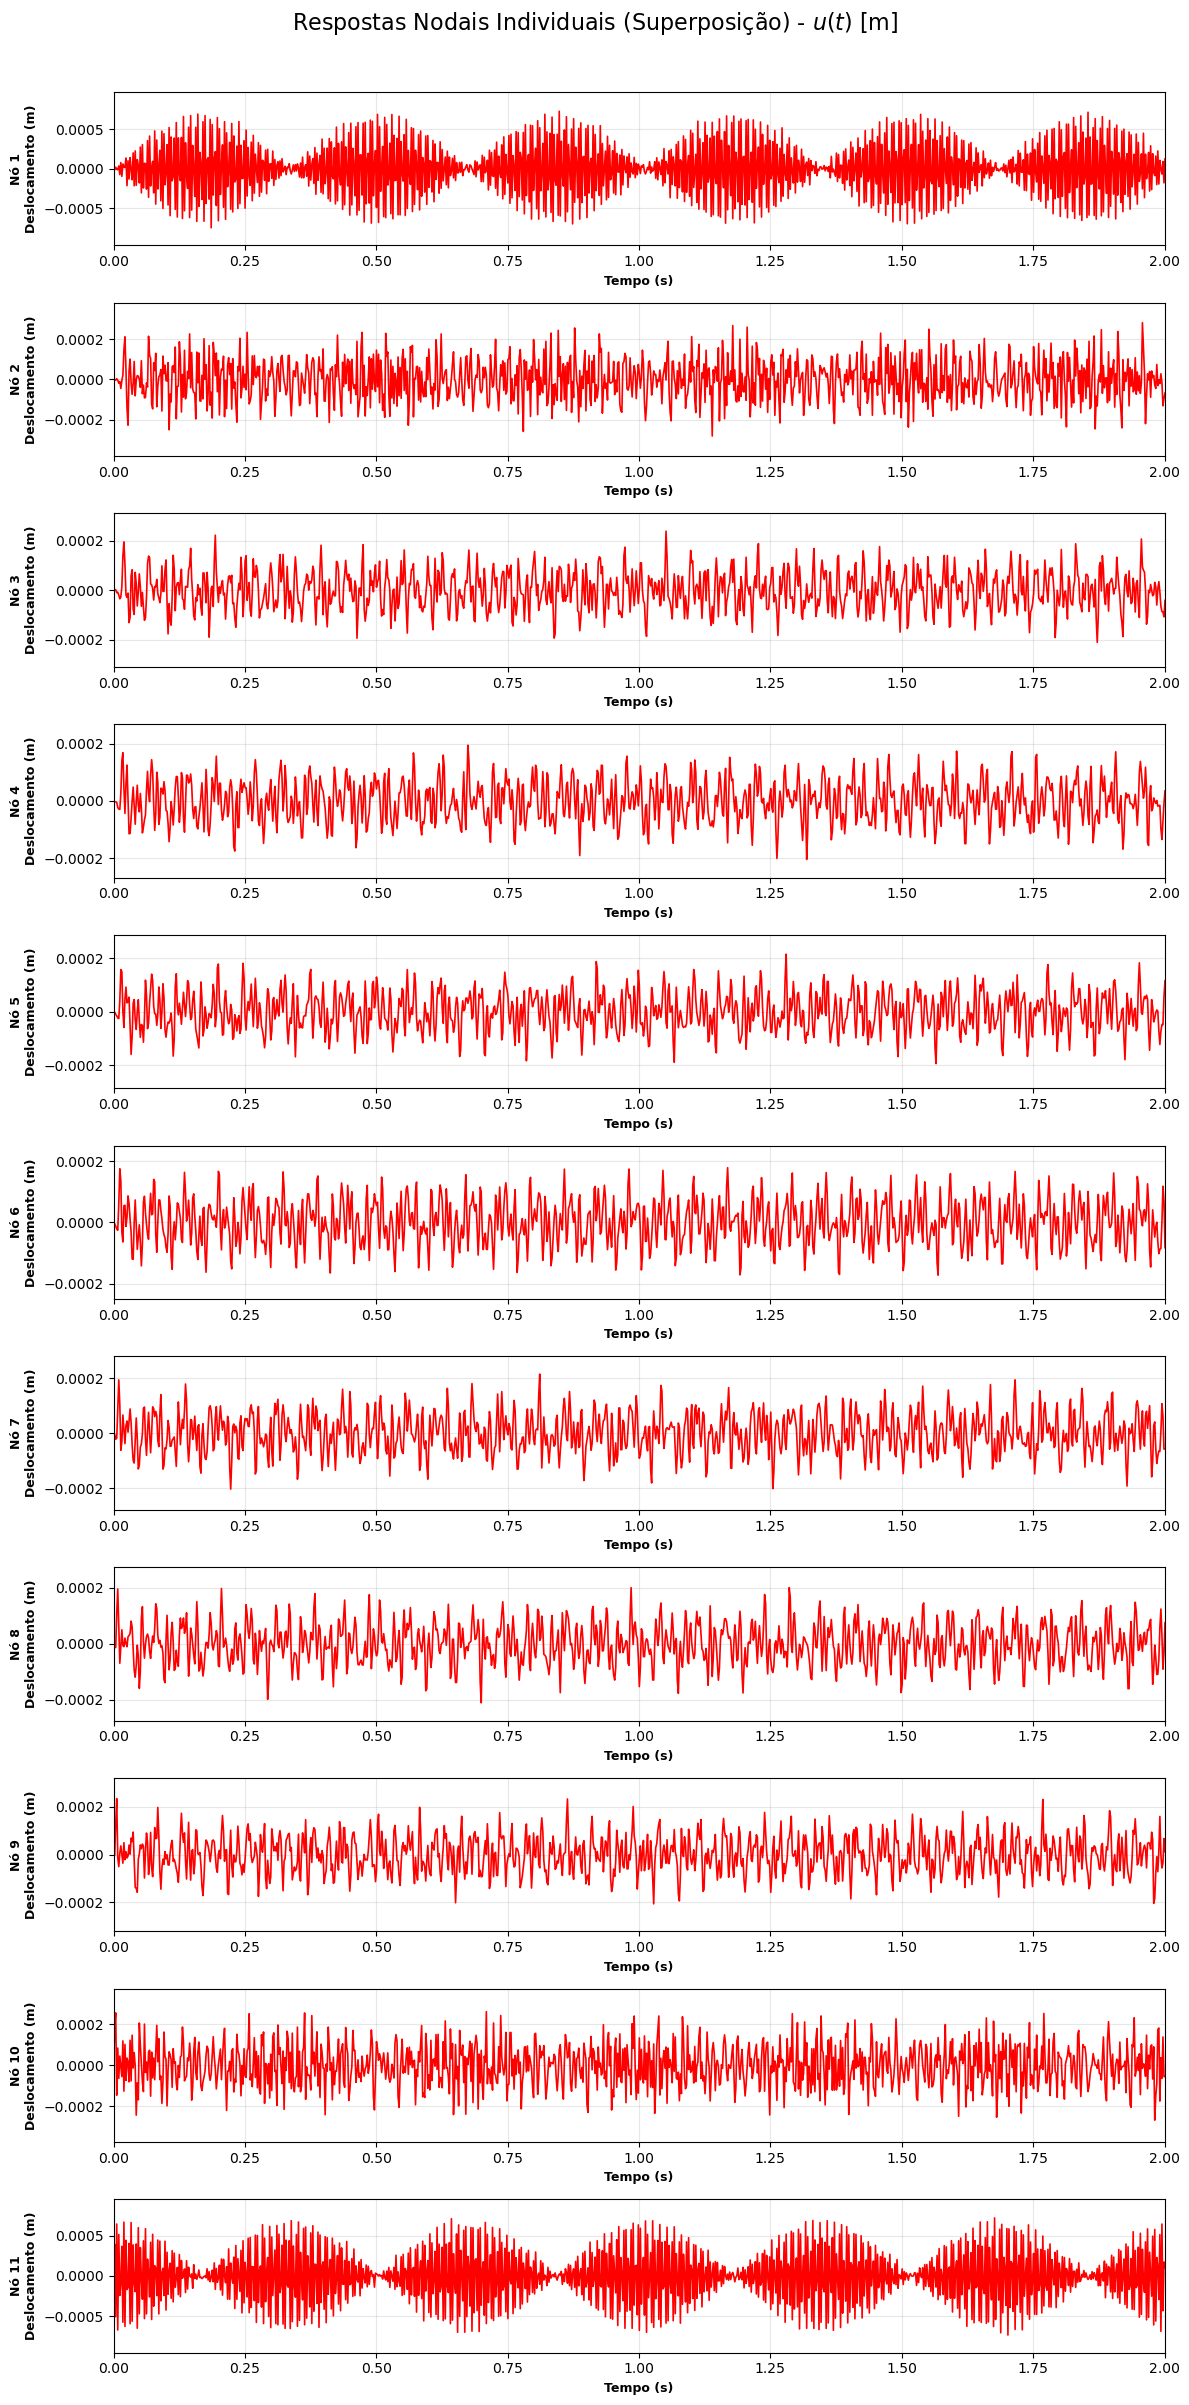

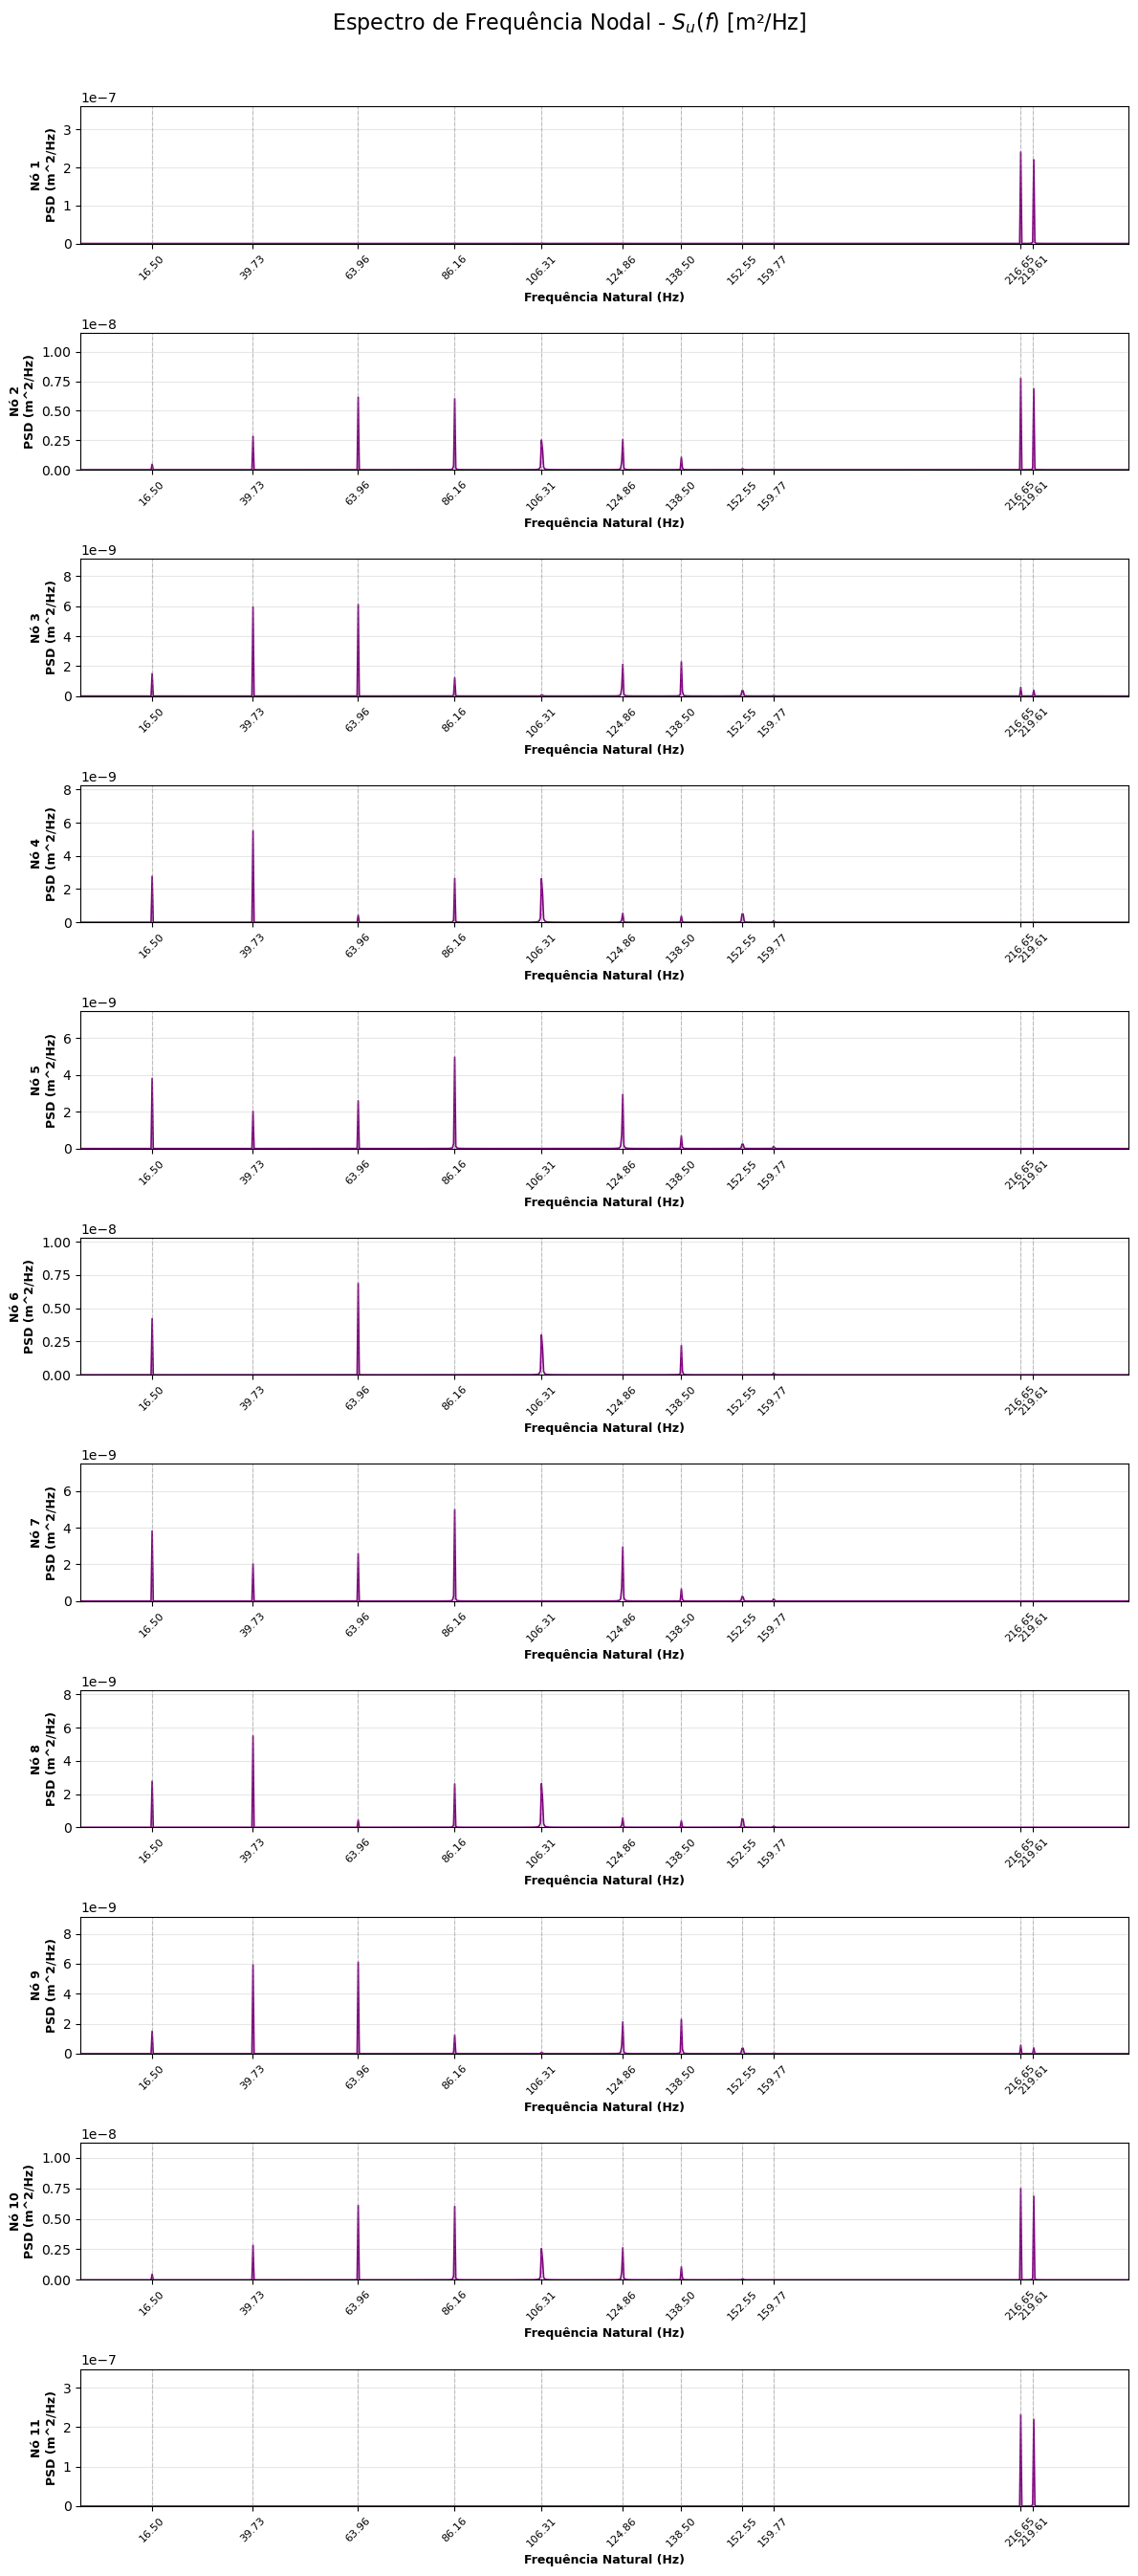


--- TABELA 1: RESULTADOS ESTATÍSTICOS DA RESPOSTA DINÂMICA ---
Nó     | Pico Máx. U(t) [m] | Valor R.M.S. [m]  
-------------------------------------------------------
Nó 01 | 7.435356e-04       | 3.444818e-04
Nó 02 | 2.945273e-04       | 1.020994e-04
Nó 03 | 2.387903e-04       | 7.582965e-05
Nó 04 | 2.059608e-04       | 7.022902e-05
Nó 05 | 2.204901e-04       | 7.069669e-05
Nó 06 | 1.923976e-04       | 7.122310e-05
Nó 07 | 2.145641e-04       | 7.064569e-05
Nó 08 | 2.107308e-04       | 7.023149e-05
Nó 09 | 2.470757e-04       | 7.576928e-05
Nó 10 | 2.874220e-04       | 1.016930e-04
Nó 11 | 7.308544e-04       | 3.410513e-04

SÍNTESE PARA CONCLUSÃO E VALIDAÇÃO FÍSICA:
1. Ponto de Excitação (Impacto):      Nó 11
2. Ponto de Resposta Máxima (Pico):   Nó 1 (7.435356e-04 m)
3. Ponto de Maior Energia (RMS):      Nó 1 (3.444818e-04 m)
---------------------------------------------------------------------------
[OBS] PROPAGAÇÃO: O maior deslocamento migrou para o Nó 1 via ondas estruturais.
[OK]

In [12]:
# =============================================================================
# 5. ANÁLISE DE RESPOSTA NO TEMPO (DOMÍNIO DO TEMPO)
# =============================================================================

# 1. Geração das respostas modais (uk) e nodais (uN)
# uk: Resposta de cada modo isolado | uN: Deslocamento real dos nós (superposição)
uk = MRPy.harmonic(NX=11, N=2048, fs=512, X0=u0i, f0=fk, phi=thi)
uN = MRPy(np.dot(Phi, uk), fs=512)
t  = uk.t_axis()

# --- PARTE A: Respostas Modais Individuais (uk) ---
fig1, axes1 = plt.subplots(11, 1, figsize=(12, 25), sharex=True)
fig1.suptitle('Respostas Modais Individuais - $u_k(t)$ [m]', fontsize=16, y=0.99)

for k in range(11):
    axes1[k].plot(t, uk[k, :], color='blue', linewidth=1.2)
    axes1[k].set_ylabel(f'Modo {k+1}\nAmplitude (m)', fontsize=9, fontweight='bold')
    axes1[k].grid(True, alpha=0.3)
    
    # Margem para o texto da frequência não sobrepor a onda
    amp_max_k = np.max(np.abs(uk[k, :]))
    if amp_max_k > 0:
        axes1[k].set_ylim(-amp_max_k * 1.8, amp_max_k * 1.8)
        axes1[k].text(0.05, amp_max_k * 1.3, f'fk = {fk[k]:.2f} Hz', 
                      fontsize=10, fontweight='bold', bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

    axes1[k].tick_params(labelbottom=True)
    axes1[k].set_xlabel('Tempo (s)', fontsize=9, fontweight='bold')

axes1[10].set_xlim(0, 2.0)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

# --- PARTE B: Respostas Nodais (uN) - Superposição de todos os modos ---
fig2, axes2 = plt.subplots(11, 1, figsize=(12, 25), sharex=True)
fig2.suptitle('Respostas Nodais Individuais (Superposição) - $u(t)$ [m]', fontsize=16, y=0.99)

for i in range(11):
    axes2[i].plot(t, uN[i, :], color='red', linewidth=1.2)
    axes2[i].set_ylabel(f'Nó {i+1}\nDeslocamento (m)', fontsize=9, fontweight='bold')
    axes2[i].grid(True, alpha=0.3)
    
    amp_max_n = np.max(np.abs(uN[i, :]))
    if amp_max_n > 0:
        axes2[i].set_ylim(-amp_max_n * 1.3, amp_max_n * 1.3)

    axes2[i].tick_params(labelbottom=True)
    axes2[i].set_xlabel('Tempo (s)', fontsize=9, fontweight='bold')

axes2[10].set_xlim(0, 2.0)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()


# =============================================================================
# 6. ANÁLISE DE RESPOSTA NA FREQUÊNCIA (DOMÍNIO DA FREQUÊNCIA)
# =============================================================================

# 1. Cálculo da Densidade Espectral (PSD) e Eixo de Frequências
S, _ = uN.periodogram()
f_axis = np.linspace(0, 512/2, 2048//2 + 1)

fig3, axes3 = plt.subplots(11, 1, figsize=(12, 28), sharex=True)
fig3.suptitle('Espectro de Frequência Nodal - $S_u(f)$ [m²/Hz]', fontsize=16, y=0.99)

for i in range(11):
    axes3[i].plot(f_axis, S[i, :], color='purple', linewidth=1.2)
    axes3[i].set_ylabel(f'Nó {i+1}\nPSD (m^2/Hz)', fontsize=9, fontweight='bold')
    axes3[i].grid(True, alpha=0.3)
    
    # Marcação visual das frequências naturais (linhas verticais)
    for freq in fk:
        axes3[i].axvline(freq, color='gray', linestyle='--', linewidth=0.8, alpha=0.4)

    # REFINAMENTO DO EIXO X: Plotar todas as fk com 2 casas decimais
    axes3[i].set_xticks(fk)
    axes3[i].set_xticklabels([f"{val:.2f}" for val in fk], rotation=45, fontsize=8)
    
    s_max = np.max(S[i, :])
    if s_max > 0:
        axes3[i].set_ylim(0, s_max * 1.5)

    axes3[i].tick_params(labelbottom=True)
    axes3[i].set_xlabel('Frequência Natural (Hz)', fontsize=9, fontweight='bold')

# Ajuste do limite X para englobar todas as frequências calculadas
axes3[10].set_xlim(0, max(fk) * 1.1) 
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()


# =============================================================================
# 7. ESTATÍSTICAS, TABELAS E SÍNTESE FINAL
# =============================================================================

# Identificação do ponto de aplicação do impacto
gdl_excitado = np.argmax(np.abs(v0)) + 1

print("\n--- TABELA 1: RESULTADOS ESTATÍSTICOS DA RESPOSTA DINÂMICA ---")
print(f"{'Nó':<6} | {'Pico Máx. U(t) [m]':<18} | {'Valor R.M.S. [m]':<18}")
print("-" * 55)

picos_list, rms_list = [], []

for i in range(11):
    pico_u = np.max(np.abs(uN[i, :]))
    valor_rms = uN[i, :].std()
    picos_list.append(pico_u)
    rms_list.append(valor_rms)
    print(f"Nó {i+1:02d} | {pico_u:.6e}       | {valor_rms:.6e}")

# --- SÍNTESE E VALIDAÇÃO DE COERÊNCIA ---
no_pico_max = np.argmax(picos_list) + 1
no_rms_max  = np.argmax(rms_list) + 1

print("\n" + "="*75)
print("SÍNTESE PARA CONCLUSÃO E VALIDAÇÃO FÍSICA:")
print(f"1. Ponto de Excitação (Impacto):      Nó {gdl_excitado}")
print(f"2. Ponto de Resposta Máxima (Pico):   Nó {no_pico_max} ({max(picos_list):.6e} m)")
print(f"3. Ponto de Maior Energia (RMS):      Nó {no_rms_max} ({max(rms_list):.6e} m)")

print("-" * 75)
# Verificação 1: Onde foi o impacto é onde deu o maior deslocamento?
if no_pico_max == gdl_excitado:
    print(f"[OK] VALIDAÇÃO: O Nó {no_pico_max} (Impacto) apresentou o maior deslocamento instantâneo.")
else:
    print(f"[OBS] PROPAGAÇÃO: O maior deslocamento migrou para o Nó {no_pico_max} via ondas estruturais.")

# Verificação 2: O pico e o RMS coincidem no mesmo nó?
if no_pico_max == no_rms_max:
    print(f"[OK] COERÊNCIA: O Nó {no_pico_max} concentra tanto o pico quanto a maior energia vibratória.")
else:
    print(f"[OBS] DISTRIBUIÇÃO: A energia (RMS) e o Pico divergiram entre os nós {no_pico_max} e {no_rms_max}.")

print("="*75)

#### PELO CRITÉRIO ESTÁTICO

In [13]:
# =========================================================
# 1. VETORES DE CONDIÇÃO INICIAL
# =========================================================
# u0: Vetor coluna com os deslocamentos iniciais (m)
u0 = np.array([[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]]).T

# v0: Vetor coluna com as velocidades iniciais (m/s)
v0 = np.array([[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0]]).T

print("--- 1. Condições Iniciais Físicas ---")
print("Vetor de Deslocamentos u0 (m):")
print(u0.T)
print("\nVetor de Velocidades v0 (m/s):")
print(v0.T)


# =========================================================
# 2. PROPRIEDADES MODAIS (Massa Modal)
# =========================================================
# Mi_mat: Matriz de massa modal completa (Phi.T * M * Phi)
Mi_mat = np.dot(np.dot(Phi.T, M), Phi)   

print("\n--- 2. Massa Modal ---")
print("Matriz de Massa Modal Completa (deve ser diagonal):")
print(np.round(Mi_mat, 4))

# Mi: Extrai apenas a diagonal principal para os cálculos
Mi = np.diag(Mi_mat)
print("\nVetor da diagonal principal (Mi) para cada modo:")
print(np.round(Mi, 4))


# =========================================================
# 3. PROJEÇÃO MODAL DAS CONDIÇÕES INICIAIS
# =========================================================
# O .flatten() achata a matriz coluna para um vetor 1D simples
qMu0 = np.dot(np.dot(Phi.T, M), u0).flatten()
qMv0 = np.dot(np.dot(Phi.T, M), v0).flatten()

print("\n--- 3. Projeção das Condições Iniciais no Espaço Modal ---")
print("Deslocamentos projetados (qMu0):")
print(np.round(qMu0, 4))
print("\nVelocidades projetadas (qMv0):")
print(np.round(qMv0, 4))

print()

# =========================================================
# 4. CÁLCULO DE FASE (thi) E AMPLITUDE (u0i) - AUTOMATIZADO
# =========================================================
# Este bloco resolve a resposta para cada um dos 11 modos
# sem necessidade de ajustes manuais para u0 ou v0.

print("\n--- 4. CÁLCULO DE FASE (thi) E AMPLITUDE (u0i) ---")

thi = np.zeros(11)
u0i = np.zeros(11)

print(f"{'Modo':<8} | {'Fase (rad)':<12} | {'Amplitude (mm)':<15}")


for k in range(11):
    # O uso do arctan2(numerador, denominador) evita erros de divisão por zero
    # thi = arctan( (w*qMu0) / qMv0 )
    thi[k] = np.arctan2(wk[k] * qMu0[k], qMv0[k])
    
    # Amplitude calculada pela raiz da soma dos quadrados (vetor resultante)
    # u0i = sqrt( (u0_modal)^2 + (v0_modal/w)^2 )
    # Nota: Dividimos por Mi[k] para normalizar pela massa modal do modo k
    termo_u = qMu0[k] / Mi[k]
    termo_v = qMv0[k] / (Mi[k] * wk[k])
    
    u0i[k] = np.sqrt(termo_u**2 + termo_v**2)
        
    print(f"Modo {k+1:02d}  | {thi[k]:10.4f}   | {1000*u0i[k]:12.6f}")

--- 1. Condições Iniciais Físicas ---
Vetor de Deslocamentos u0 (m):
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]

Vetor de Velocidades v0 (m/s):
[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]]

--- 2. Massa Modal ---
Matriz de Massa Modal Completa (deve ser diagonal):
[[ 1.  0.  0.  0. -0.  0.  0. -0.  0.  0.  0.]
 [ 0.  1.  0. -0. -0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  1. -0.  0.  0.  0.  0. -0. -0. -0.]
 [ 0. -0. -0.  1.  0. -0.  0.  0. -0. -0.  0.]
 [-0. -0.  0.  0.  1.  0.  0. -0.  0.  0.  0.]
 [ 0.  0.  0. -0.  0.  1.  0.  0.  0. -0. -0.]
 [ 0.  0.  0.  0.  0.  0.  1.  0.  0. -0.  0.]
 [-0.  0.  0.  0. -0.  0.  0.  1. -0.  0. -0.]
 [ 0.  0. -0. -0.  0.  0.  0. -0.  1. -0.  0.]
 [ 0.  0. -0. -0.  0. -0. -0.  0. -0.  1.  0.]
 [ 0.  0. -0.  0.  0. -0.  0. -0.  0.  0.  1.]]

Vetor da diagonal principal (Mi) para cada modo:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

--- 3. Projeção das Condições Iniciais no Espaço Modal ---
Deslocamentos projetados (qMu0):
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Velocidades proje

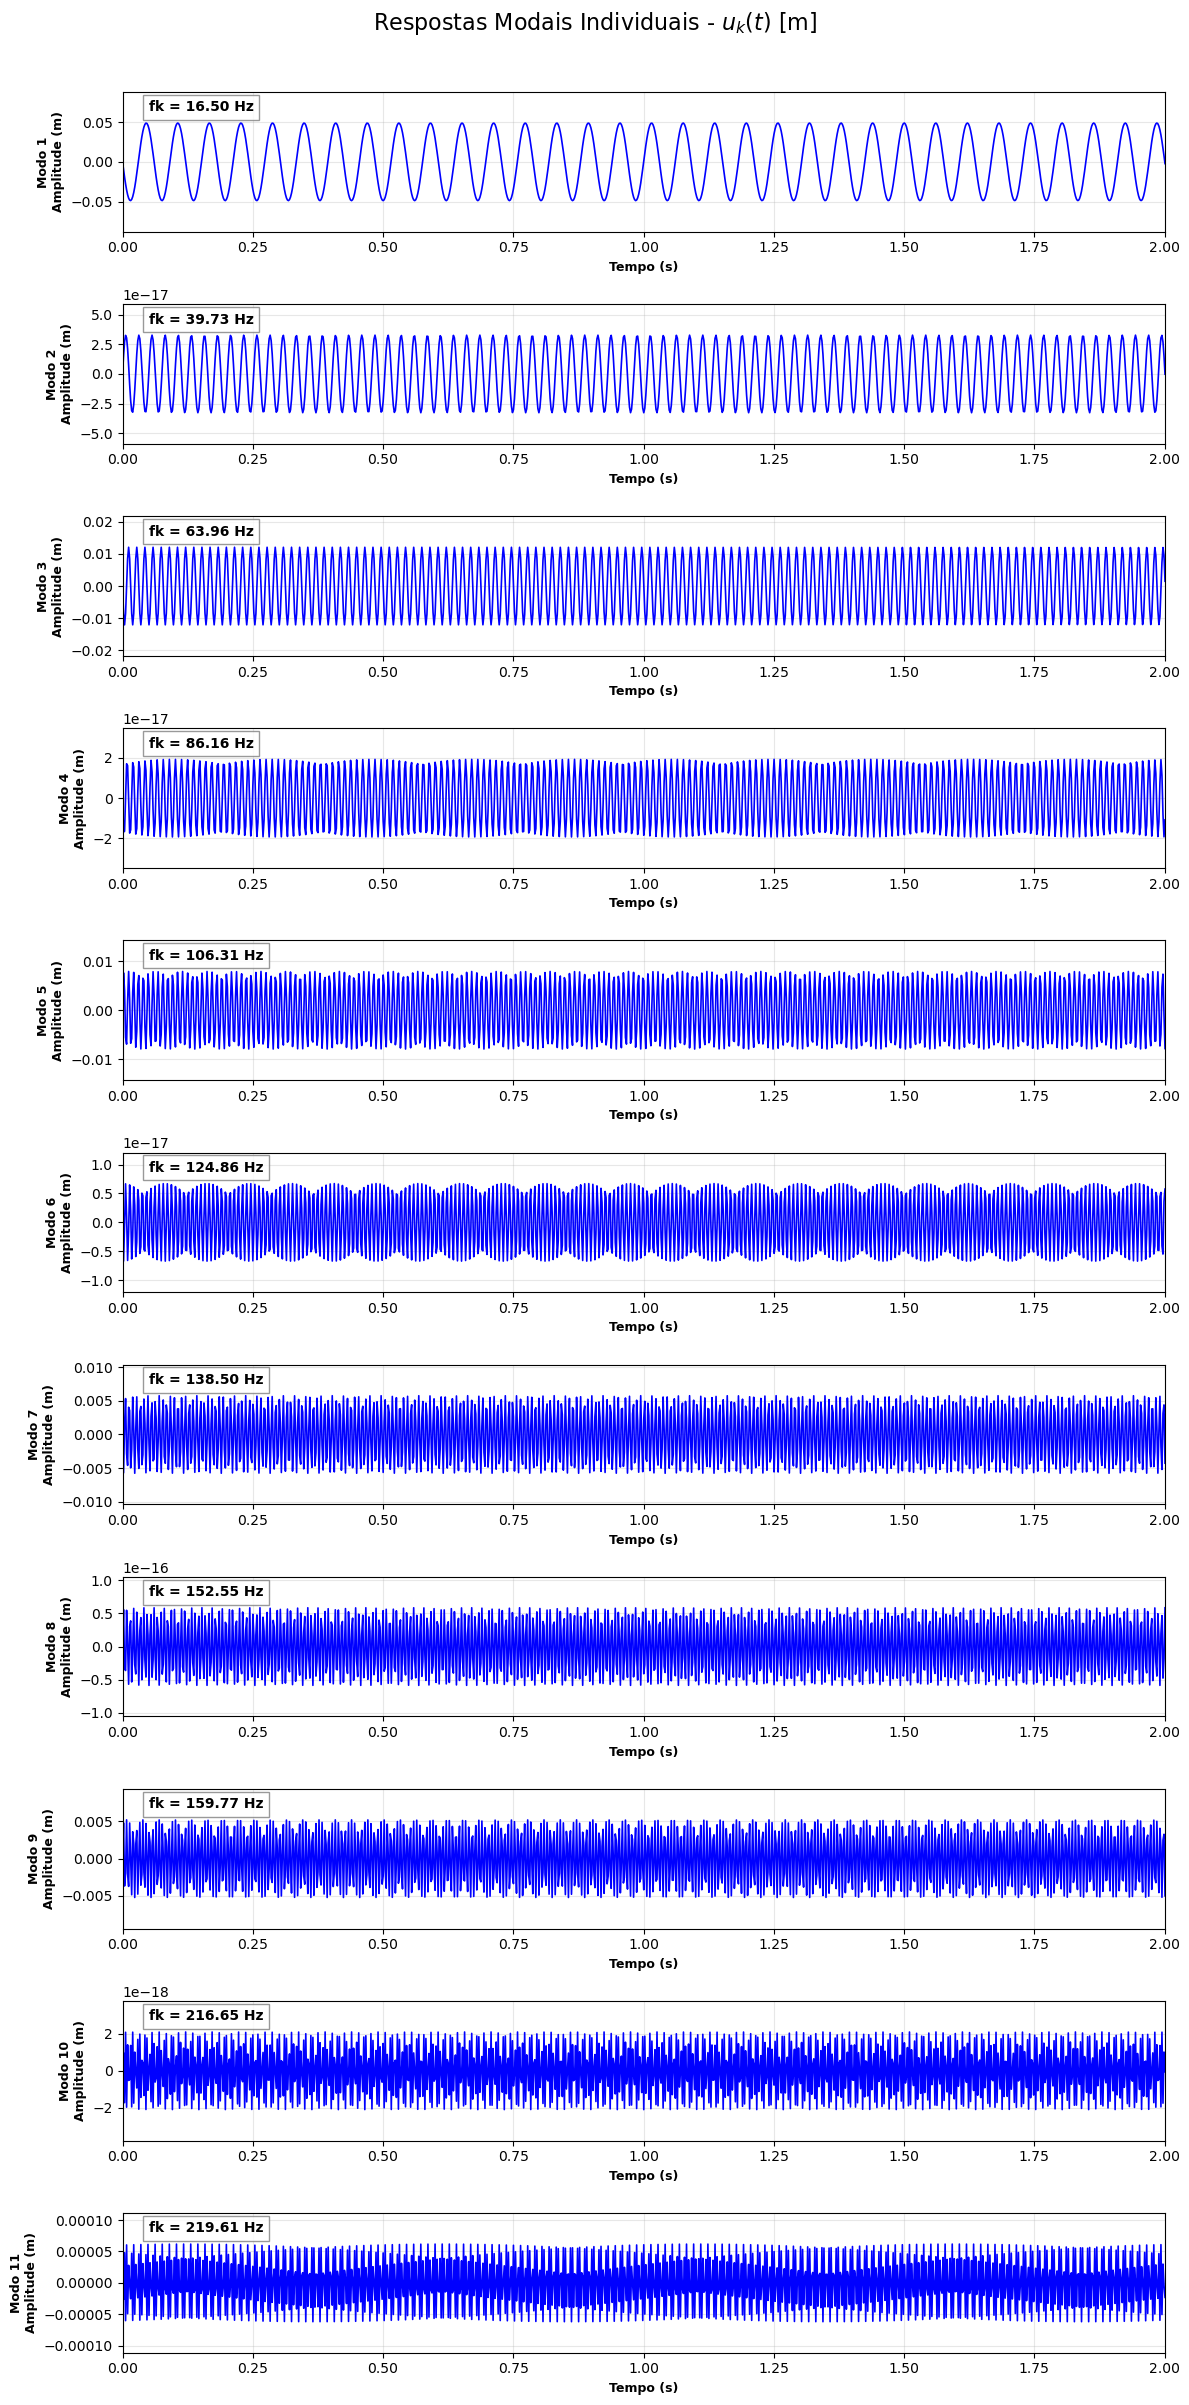

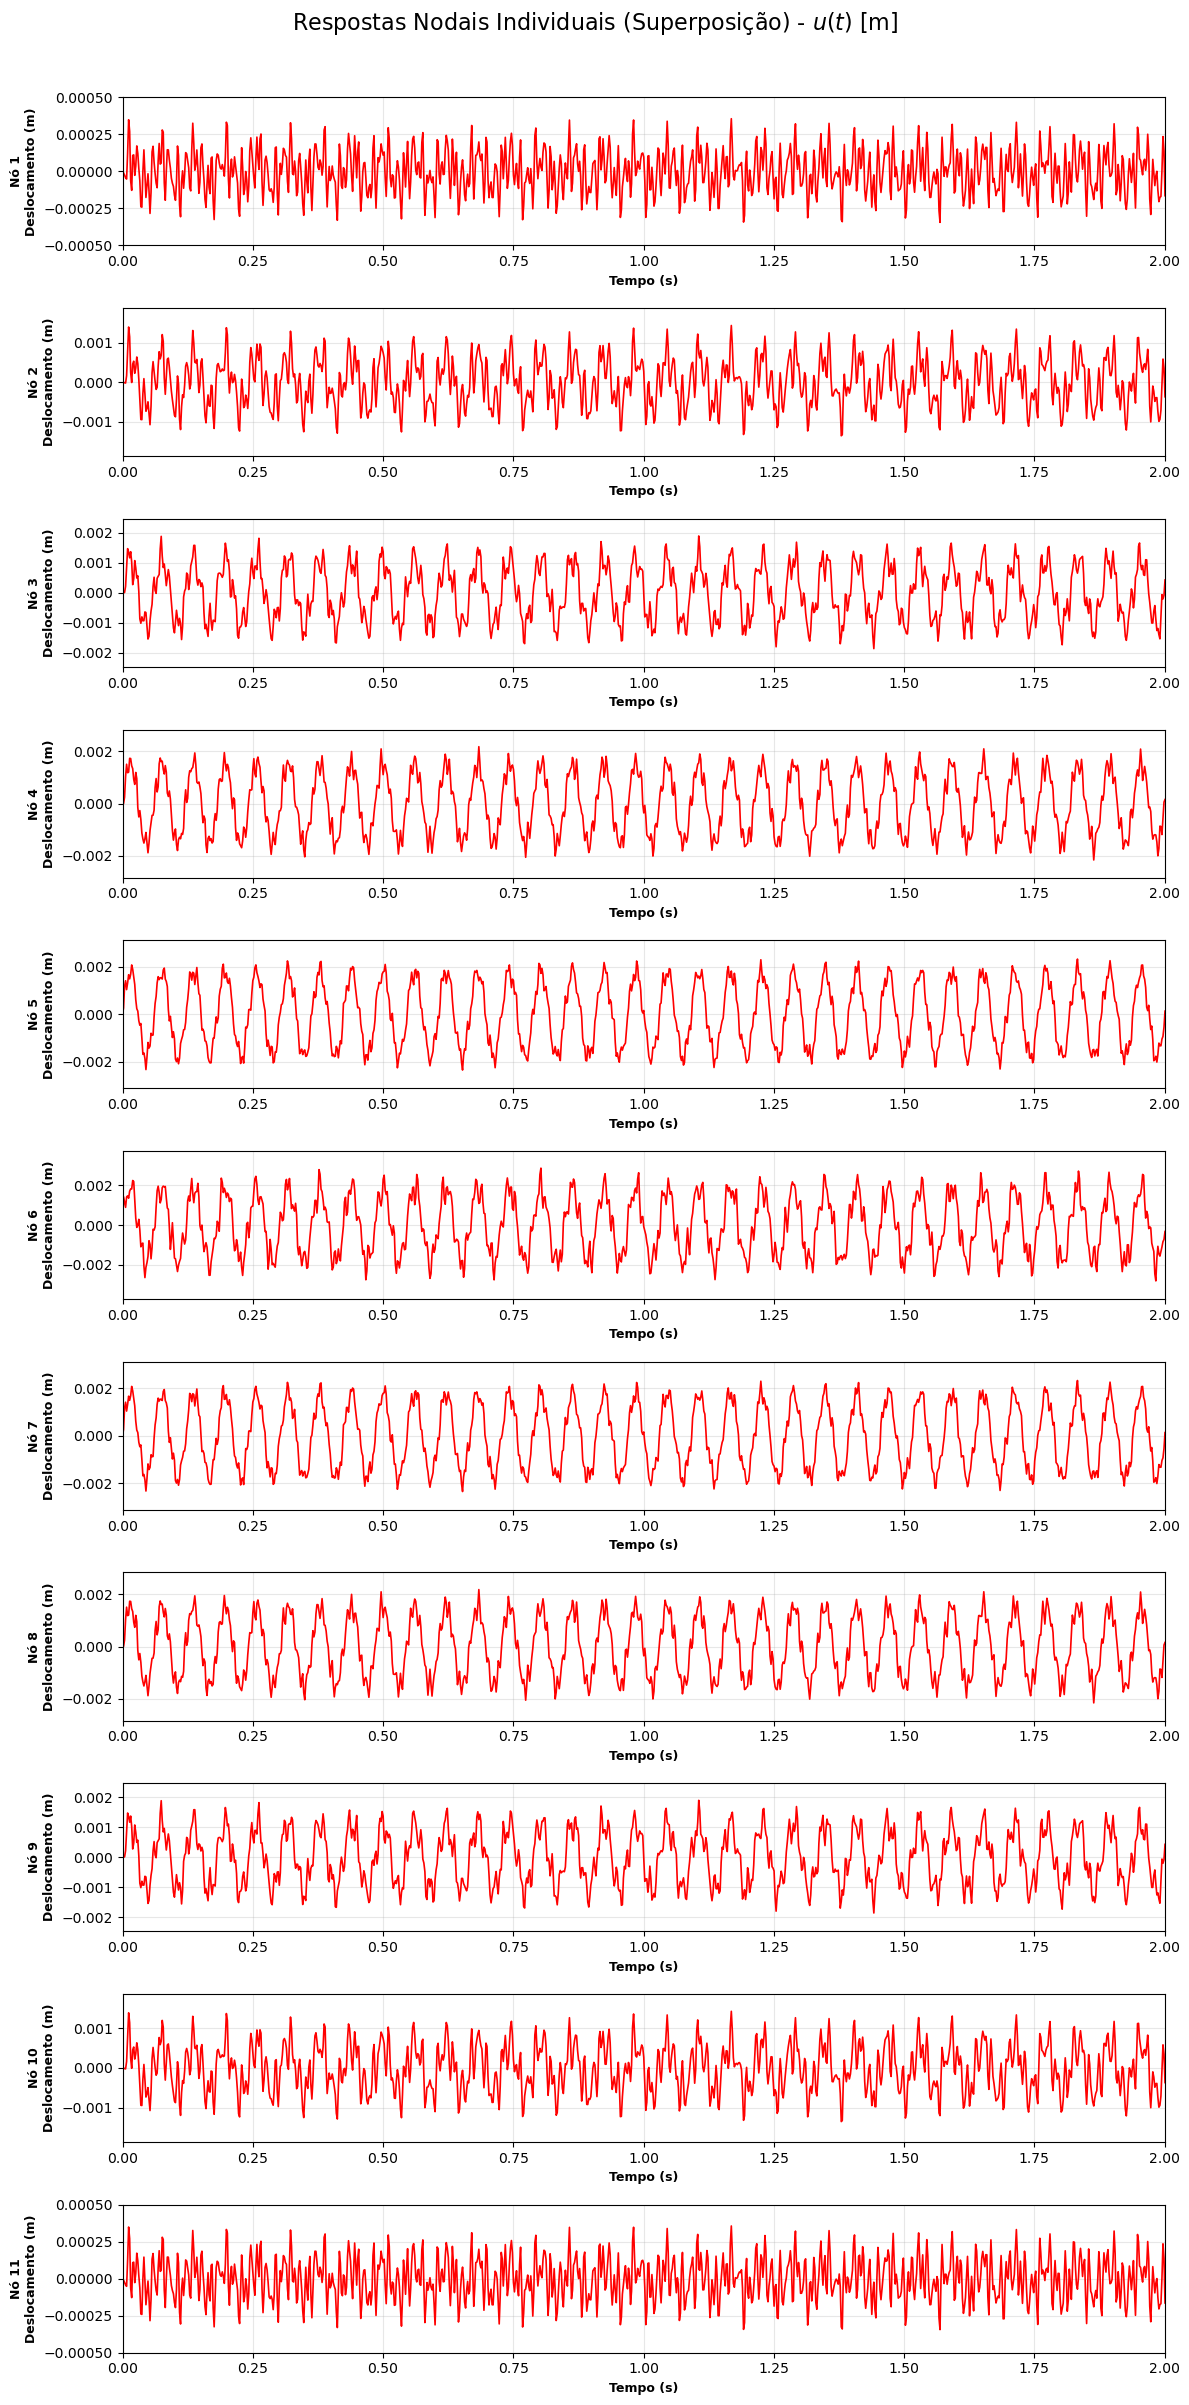

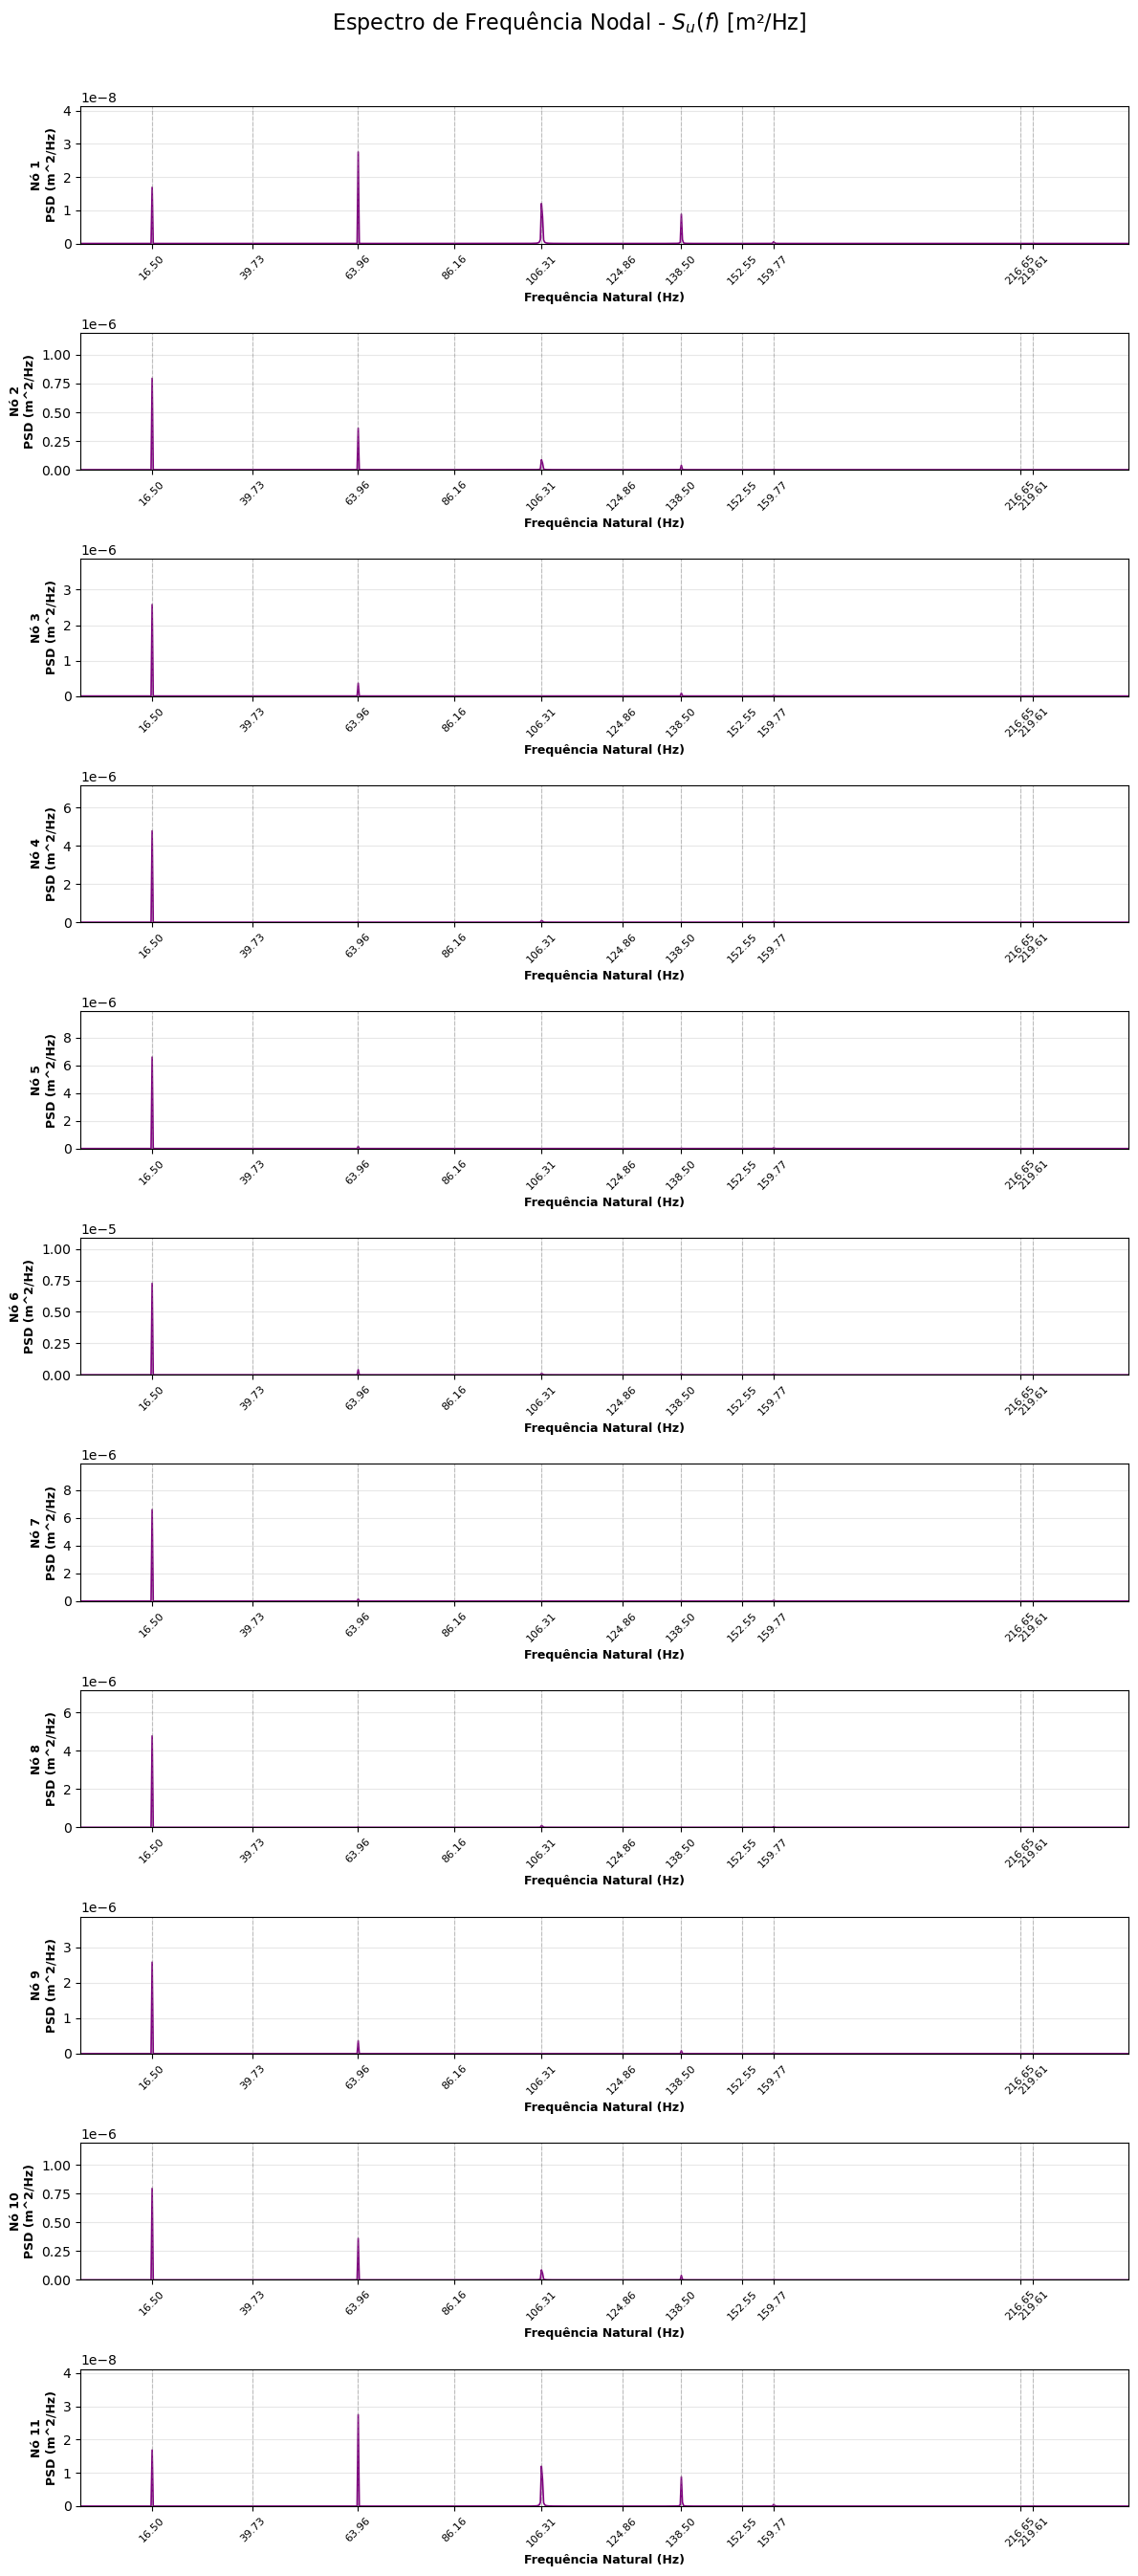


--- TABELA 1: RESULTADOS ESTATÍSTICOS DA RESPOSTA DINÂMICA ---
Nó     | Pico Máx. U(t) [m] | Valor R.M.S. [m]  
-------------------------------------------------------
Nó 01 | 3.850983e-04       | 1.425584e-04
Nó 02 | 1.440409e-03       | 5.895411e-04
Nó 03 | 1.898765e-03       | 8.771372e-04
Nó 04 | 2.180842e-03       | 1.125860e-03
Nó 05 | 2.398095e-03       | 1.308687e-03
Nó 06 | 2.873826e-03       | 1.420801e-03
Nó 07 | 2.398095e-03       | 1.308687e-03
Nó 08 | 2.180842e-03       | 1.125860e-03
Nó 09 | 1.898765e-03       | 8.771372e-04
Nó 10 | 1.440409e-03       | 5.895411e-04
Nó 11 | 3.850983e-04       | 1.425584e-04

SÍNTESE PARA CONCLUSÃO E VALIDAÇÃO FÍSICA:
1. Ponto de Excitação (Impacto):      Nó 6
2. Ponto de Resposta Máxima (Pico):   Nó 6 (2.873826e-03 m)
3. Ponto de Maior Energia (RMS):      Nó 6 (1.420801e-03 m)
---------------------------------------------------------------------------
[OK] VALIDAÇÃO: O Nó 6 (Impacto) apresentou o maior deslocamento instantâneo.
[OK] COE

In [14]:
# =============================================================================
# 5. ANÁLISE DE RESPOSTA NO TEMPO (DOMÍNIO DO TEMPO)
# =============================================================================

# 1. Geração das respostas modais (uk) e nodais (uN)
# uk: Resposta de cada modo isolado | uN: Deslocamento real dos nós (superposição)
uk = MRPy.harmonic(NX=11, N=2048, fs=512, X0=u0i, f0=fk, phi=thi)
uN = MRPy(np.dot(Phi, uk), fs=512)
t  = uk.t_axis()

# --- PARTE A: Respostas Modais Individuais (uk) ---
fig1, axes1 = plt.subplots(11, 1, figsize=(12, 25), sharex=True)
fig1.suptitle('Respostas Modais Individuais - $u_k(t)$ [m]', fontsize=16, y=0.99)

for k in range(11):
    axes1[k].plot(t, uk[k, :], color='blue', linewidth=1.2)
    axes1[k].set_ylabel(f'Modo {k+1}\nAmplitude (m)', fontsize=9, fontweight='bold')
    axes1[k].grid(True, alpha=0.3)
    
    # Margem para o texto da frequência não sobrepor a onda
    amp_max_k = np.max(np.abs(uk[k, :]))
    if amp_max_k > 0:
        axes1[k].set_ylim(-amp_max_k * 1.8, amp_max_k * 1.8)
        axes1[k].text(0.05, amp_max_k * 1.3, f'fk = {fk[k]:.2f} Hz', 
                      fontsize=10, fontweight='bold', bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

    axes1[k].tick_params(labelbottom=True)
    axes1[k].set_xlabel('Tempo (s)', fontsize=9, fontweight='bold')

axes1[10].set_xlim(0, 2.0)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

# --- PARTE B: Respostas Nodais (uN) - Superposição de todos os modos ---
fig2, axes2 = plt.subplots(11, 1, figsize=(12, 25), sharex=True)
fig2.suptitle('Respostas Nodais Individuais (Superposição) - $u(t)$ [m]', fontsize=16, y=0.99)

for i in range(11):
    axes2[i].plot(t, uN[i, :], color='red', linewidth=1.2)
    axes2[i].set_ylabel(f'Nó {i+1}\nDeslocamento (m)', fontsize=9, fontweight='bold')
    axes2[i].grid(True, alpha=0.3)
    
    amp_max_n = np.max(np.abs(uN[i, :]))
    if amp_max_n > 0:
        axes2[i].set_ylim(-amp_max_n * 1.3, amp_max_n * 1.3)

    axes2[i].tick_params(labelbottom=True)
    axes2[i].set_xlabel('Tempo (s)', fontsize=9, fontweight='bold')

axes2[10].set_xlim(0, 2.0)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()


# =============================================================================
# 6. ANÁLISE DE RESPOSTA NA FREQUÊNCIA (DOMÍNIO DA FREQUÊNCIA)
# =============================================================================

# 1. Cálculo da Densidade Espectral (PSD) e Eixo de Frequências
S, _ = uN.periodogram()
f_axis = np.linspace(0, 512/2, 2048//2 + 1)

fig3, axes3 = plt.subplots(11, 1, figsize=(12, 28), sharex=True)
fig3.suptitle('Espectro de Frequência Nodal - $S_u(f)$ [m²/Hz]', fontsize=16, y=0.99)

for i in range(11):
    axes3[i].plot(f_axis, S[i, :], color='purple', linewidth=1.2)
    axes3[i].set_ylabel(f'Nó {i+1}\nPSD (m^2/Hz)', fontsize=9, fontweight='bold')
    axes3[i].grid(True, alpha=0.3)
    
    # Marcação visual das frequências naturais (linhas verticais)
    for freq in fk:
        axes3[i].axvline(freq, color='gray', linestyle='--', linewidth=0.8, alpha=0.4)

    # REFINAMENTO DO EIXO X: Plotar todas as fk com 2 casas decimais
    axes3[i].set_xticks(fk)
    axes3[i].set_xticklabels([f"{val:.2f}" for val in fk], rotation=45, fontsize=8)
    
    s_max = np.max(S[i, :])
    if s_max > 0:
        axes3[i].set_ylim(0, s_max * 1.5)

    axes3[i].tick_params(labelbottom=True)
    axes3[i].set_xlabel('Frequência Natural (Hz)', fontsize=9, fontweight='bold')

# Ajuste do limite X para englobar todas as frequências calculadas
axes3[10].set_xlim(0, max(fk) * 1.1) 
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()


# =============================================================================
# 7. ESTATÍSTICAS, TABELAS E SÍNTESE FINAL
# =============================================================================

# Identificação do ponto de aplicação do impacto
gdl_excitado = np.argmax(np.abs(v0)) + 1

print("\n--- TABELA 1: RESULTADOS ESTATÍSTICOS DA RESPOSTA DINÂMICA ---")
print(f"{'Nó':<6} | {'Pico Máx. U(t) [m]':<18} | {'Valor R.M.S. [m]':<18}")
print("-" * 55)

picos_list, rms_list = [], []

for i in range(11):
    pico_u = np.max(np.abs(uN[i, :]))
    valor_rms = uN[i, :].std()
    picos_list.append(pico_u)
    rms_list.append(valor_rms)
    print(f"Nó {i+1:02d} | {pico_u:.6e}       | {valor_rms:.6e}")

# --- SÍNTESE E VALIDAÇÃO DE COERÊNCIA ---
no_pico_max = np.argmax(picos_list) + 1
no_rms_max  = np.argmax(rms_list) + 1

print("\n" + "="*75)
print("SÍNTESE PARA CONCLUSÃO E VALIDAÇÃO FÍSICA:")
print(f"1. Ponto de Excitação (Impacto):      Nó {gdl_excitado}")
print(f"2. Ponto de Resposta Máxima (Pico):   Nó {no_pico_max} ({max(picos_list):.6e} m)")
print(f"3. Ponto de Maior Energia (RMS):      Nó {no_rms_max} ({max(rms_list):.6e} m)")

print("-" * 75)
# Verificação 1: Onde foi o impacto é onde deu o maior deslocamento?
if no_pico_max == gdl_excitado:
    print(f"[OK] VALIDAÇÃO: O Nó {no_pico_max} (Impacto) apresentou o maior deslocamento instantâneo.")
else:
    print(f"[OBS] PROPAGAÇÃO: O maior deslocamento migrou para o Nó {no_pico_max} via ondas estruturais.")

# Verificação 2: O pico e o RMS coincidem no mesmo nó?
if no_pico_max == no_rms_max:
    print(f"[OK] COERÊNCIA: O Nó {no_pico_max} concentra tanto o pico quanto a maior energia vibratória.")
else:
    print(f"[OBS] DISTRIBUIÇÃO: A energia (RMS) e o Pico divergiram entre os nós {no_pico_max} e {no_rms_max}.")

print("="*75)